<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>51095 מודלי יסוד: ארכיטקטורות, אימון ויישור</p>
<p>מטלת בית 1</p>
<p>שם: נדב פיירמן שטרן</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>מבנה המחברת:</p>
<ul>
<li>חלק א׳ — טביעת האצבע של הטוקנייזר: כיצד אותו תוכן מיוצג כרצף טוקנים, והשוואה בין טוקנייזרים.</li>
<li>חלק ב׳ — דקודינג: אותה התפלגות טוקן-הבא מייצרת תשובות שונות לפי אסטרטגיית הדגימה.</li>
<li>חלק ג׳ — הקשר, מיקום וזיכרון: כיצד אורך ומיקום המידע בחלון ההקשר משפיעים על היכולת להשתמש בו.</li>
<li>חלק ד׳ — סקיילינג: השוואה אמפירית בין שלושה גדלים באותה משפחה, איכות מול עלות חישובית.</li>
<li>חלק ה׳ — יעילות הסקה: מטמון KV, אורך פלט, פירוק העלות ל-prefill מול decode, ופענוח ספקולטיבי.</li>
<li>חלק ו׳ — Failure Forensics: איסוף שיטתי של כשלים ובניית טקסונומיה.</li>
<li>דו"ח פורנזי מסכם, ולאחריו בונוס: סוויפ קוונטיזציה על אותו מודל בשלוש רמות דיוק.</li>
</ul>
<p>המשפחה היא Qwen2.5-Instruct בשלושה גדלים, 0.5B, 1.5B ו-3B, כולם ב-bf16 עם טוקנייזר משותף. הזוג הראשי הוא 0.5B מול 3B, והגודל האמצעי מוסיף נקודה שלישית לעקומת הסקיילינג בחלק ד׳.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>תקציר מנהלים:</p>
<p>שלושה גדלים של Qwen2.5-Instruct נחקרו כקופסה שחורה בשישה ניסויים ובבונוס. הממצא החזק ביותר הוא שמיקום המידע בהקשר קובע יותר מאורכו: עובדה שהושתלה בסוף המסמך אוחזרה ב-24 מתוך 24 התנאים, בשני הגדלים ובשלוש הבדיקות, בעוד האמצע נשבר אצל 0.5B כבר ב-8 אלף טוקנים ואצל 3B ב-30 אלף. בשני הגדלים שנבדקו הגדלת המודל לא ביטלה את התופעה אלא דחתה את הסף. אותה תבנית של תשואה לא אחידה חוזרת בסקיילינג: הציון הכולל עולה 0.333, 0.583 ו-0.750, אך אף סוג משימה אינו משתפר בשתי המדרגות — קוד מגיע לתקרה כבר ב-1.5B בעוד ההנמקה נשארת מהנמוכות גם ב-3B, וניסוי ה-minimal pair הראה שאצל המודל הקטן אף אחד מארבעת הנוסחים שנבדקו לא הציל אותה.</p>
<ul>
<li>הממצא המרכזי: הטיית recency חוצה את כל בדיקות ההקשר — 24 מתוך 24 בסוף המסמך, מול קריסה באמצע שסִפָּהּ תלוי בגודל המודל</li>
<li>הטרייד-אוף המרכזי שנמדד: פי 6.25 במשקולות קונה פי 2.25 בציון, ואילו מטמון ה-KV קונה עד פי 7.8 בלי לשנות פרמטר אחד. מודל 3B ב-4-bit תופס 1.914 GiB ומשיג 0.708, מול 1.5B ב-bf16 עם 2.875 ו-0.583 — קטן יותר וגם טוב יותר</li>
<li>ההסתייגות המרכזית: ה-benchmark מונה 24 פריטים, כלומר 0.167 לפריט בכל סוג משימה. כל הפרש של פריט או שניים מדווח כאן כמגמה ולא כאומדן, וכל המסקנות נוגעות להתנהגות קלט-פלט בלבד</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>עקרונות תכנון הניסוי:</p>
<ul>
<li>שינוי גורם אחד בכל ניסוי. שלושת הגדלים רצים ב-bf16 עם אותו טוקנייזר ואותה תבנית שיחה, כך שהשוואת הגדלים משנה משתנה יחיד</li>
<li>פענוח greedy בכל מקום שבו האקראיות אינה מושא הניסוי, כלומר בחלקים ג׳, ד׳ ובבונוס</li>
<li>חמש הרצות בכל תצורה שכוללת דגימה, עם seed מתועד. לא מדווחת תוצאה בודדת כאשר קיימת אקראיות משמעותית</li>
<li>כל המדדים הוגדרו בתאי ההגדרות של כל חלק לפני ההרצה, ולא נבחרו בדיעבד</li>
<li>הכשלים נאספו אוטומטית ברגע שתשובה לא עמדה בקריטריון שהוגדר מראש, ולא נבחרו בדיעבד</li>
<li>הפרדה קבועה בין עובדה מתיעוד המודל, תוצאה אמפירית שנמדדה כאן, ומסקנה שהוסקה מהמדידה</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>התקנת ספריות.</p>
<ul>
<li>transformers — טעינת המודלים והטוקנייזרים</li>
<li>accelerate — שליטה במיקום המודל על הכרטיס</li>
<li>bitsandbytes — קוונטיזציה ב-8-bit וב-4-bit בבונוס</li>
<li>sentencepiece — טוקנייזרים של משפחות אחרות בחלק א׳</li>
</ul>
<p>אם Colab מבקש הפעלה מחדש של ה-runtime לאחר ההתקנה, יש לאשר ולהריץ מחדש מהתא הראשון.</p>
</div>

In [ ]:
!pip install -q -U transformers accelerate bitsandbytes sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 54.6 MB/s eta 0:00:00


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ייבוא והגדרת הסביבה:</p>
<ul>
<li>os — קריאת משתני סביבה וגודל קבצים</li>
<li>gc — הפעלת איסוף הזבל לשחרור זיכרון ה-GPU בין טעינות מודל</li>
<li>re — ביטויים רגולריים: נרמול תשובות בחלק ב׳, בדיקת אילוצי פורמט וחילוץ מספרים בחלק ד׳</li>
<li>json — כתיבת מבנה התוצאות לקובץ</li>
<li>time — perf_counter לכל מדידות הזמן במחברת</li>
<li>random — קביעת ה-seed של מחולל האקראיות של פייתון</li>
<li>statistics — ממוצע וסטיית תקן של אורכי התשובות בחלק ב׳</li>
<li>warnings — הסתרת אזהרות כדי לשמור על פלט קריא</li>
<li>Counter — ספירת התשובות הזהות לחישוב העקביות בחלק ב׳</li>
<li>defaultdict — קיבוץ הפירוקים לטוקנים לפי קלט בחלק א׳</li>
<li>numpy — התאמה ליניארית לפירוק prefill מול decode בחלק ה׳, ומערכי הגרפים</li>
<li>pandas — כל טבלה במחברת נבנית כ-DataFrame ומודפסת משם, כך שכל מספר מתעדכן אוטומטית בהרצה חוזרת</li>
<li>matplotlib — חמשת הגרפים שבמחברת</li>
<li>torch — הרצת המודלים, מדידת שיא זיכרון ה-GPU, וסנכרון הכרטיס לפני ואחרי כל מדידת זמן</li>
<li>transformers — set_seed לקביעת seed גלובלי, AutoTokenizer לטוקניזציה ולתבנית השיחה, AutoModelForCausalLM לטעינת המודלים, ו-BitsAndBytesConfig לקוונטיזציה בבונוס</li>
</ul>
<p>ארבע הגדרות סביבה בסוף התא: expandable_segments מצמצם פיצול של זיכרון ה-GPU, שנוצר כאן משום שהמחברת טוענת ומשחררת מודלים שוב ושוב; השאר הן הסתרת אזהרות, סגנון הגרפים ורוחב התצוגה של הטבלאות. לבסוף נקבע GLOBAL_SEED, שממנו נגזרים כל ה-seeds בהמשך.</p>
</div>

In [ ]:
import os, sys, gc, re, json, time, random, statistics, warnings
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

import transformers
from transformers import (AutoConfig, AutoTokenizer, AutoModelForCausalLM,
                          BitsAndBytesConfig)
from huggingface_hub import login
from google.colab import files

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
warnings.filterwarnings("ignore")
plt.style.use("ggplot")
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 200)

GLOBAL_SEED = 51095

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה set_all_seeds קובעת seed לכל חמשת מקורות האקראיות: random, numpy, torch ב-CPU, torch ב-GPU ו-transformers. מקור אחד שלא נקבע מספיק כדי שהרצה חוזרת תיתן מספרים אחרים. הפונקציה נקראת בפתיחה ושוב לפני כל תצורה שכוללת דגימה, כדי שכל תצורה תתחיל מאותה נקודה.</p>
</div>

In [ ]:
def set_all_seeds(seed=GLOBAL_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    transformers.set_seed(seed)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>אתחול הסביבה ותיעודה:</p>
<ul>
<li>RESULTS — מבנה שאליו נאספות כל המדידות לאורך המחברת</li>
<li>FAILURES — כל כשל שמזוהה אוטומטית בחלקים ב׳ עד ד׳ נרשם כאן, וחלק ו׳ עובד עליו במקום לחפש כשלים מחדש</li>
<li>DTYPE — bfloat16, אותו דיוק לכל שלושת המודלים, כדי שהשוואת הגדלים תשנה משתנה יחיד</li>
<li>ENV — גרסאות, סוג הכרטיס וזיכרונו, dtype ו-seed, כנדרש בסעיף 12. נשמר ל-RESULTS ולא רק מודפס</li>
</ul>
</div>

In [ ]:
set_all_seeds()

RESULTS = {}
FAILURES = []

DTYPE = torch.bfloat16
ENV = {
    "torch": torch.__version__,
    "transformers": transformers.__version__,
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu",
    "gpu_total_gib": round(torch.cuda.get_device_properties(0).total_memory / 2**30, 1)
                     if torch.cuda.is_available() else 0.0,
    "dtype": str(DTYPE).replace("torch.", ""),
    "seed": GLOBAL_SEED,
}
RESULTS["environment"] = ENV
print(" | ".join(f"{k}={v}" for k, v in ENV.items()))

torch=2.11.0+cu128 | transformers=5.16.1 | gpu=NVIDIA L4 | gpu_total_gib=22.0 | dtype=bfloat16 | seed=51095


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ההרצה בוצעה על L4 עם 22.0 GiB זמינים — 24 GB במפרט הם 22.35 GiB, והיתר שמור לדרייבר. מספרי הזמן והזיכרון מתייחסים לכרטיס זה ואינם ניתנים להעברה לחומרה אחרת.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>בחירת המודלים ומתגי ההרצה:</p>
<ul>
<li>המשפחה — Qwen2.5-Instruct בשלושה גדלים, כולם ב-bf16 ועם טוקנייזר משותף, כך שהשוואת הגדלים משנה משתנה יחיד</li>
<li>הזוג הראשי — 0.5B מול 3B, פער של פי שישה בפרמטרים, בחלקים ב׳, ג׳ ו-ה׳; הבונוס רץ על 3B בלבד</li>
<li>הגודל האמצעי — 1.5B נוסף בחלק ד׳ בלבד, כדי שעקומת הסקיילינג תישען על שלוש נקודות ולא על שתיים</li>
<li>assistant — אותו 0.5B, בתפקיד מודל טיוטה לפענוח הספקולטיבי בחלק ה׳. שיתוף הטוקנייזר עם מודל המטרה הוא תנאי הכרחי לשיטה</li>
<li>אורכי ההקשר — 2K, 8K, 16K ו-30K, כשהאחרון קרוב לתקרת חלון ההקשר המוצהר של המשפחה, 32,768</li>
<li>רמות הדיוק בבונוס — bf16 מחלק ד׳, ולצדו 8-bit ו-4-bit</li>
</ul>
</div>

In [ ]:
MODEL_IDS = {
    "small":     "Qwen/Qwen2.5-0.5B-Instruct",
    "mid":       "Qwen/Qwen2.5-1.5B-Instruct",
    "large":     "Qwen/Qwen2.5-3B-Instruct",
    "assistant": "Qwen/Qwen2.5-0.5B-Instruct",
}
RESULTS["model_ids"] = MODEL_IDS

CONTEXT_TARGETS = [2000, 8000, 16000, 30000]
BONUS_PRECISIONS = ["8bit", "4bit"]
INCLUDE_SPECULATIVE = True

for role, mid in MODEL_IDS.items():
    print(f"  {role:10s} {mid}")
print(f"\n  context lengths : {CONTEXT_TARGETS}")
print(f"  bonus precisions: {['bf16'] + BONUS_PRECISIONS}")
print(f"  speculative     : {INCLUDE_SPECULATIVE}")

  small      Qwen/Qwen2.5-0.5B-Instruct
  mid        Qwen/Qwen2.5-1.5B-Instruct
  large      Qwen/Qwen2.5-3B-Instruct
  assistant  Qwen/Qwen2.5-0.5B-Instruct

  context lengths : [2000, 8000, 16000, 30000]
  bonus precisions: ['bf16', '8bit', '4bit']
  speculative     : True


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>המזהים המדויקים מודפסים כאן ונשמרים גם למילון RESULTS לתיעוד בזמן הריצה. revision לא ננעל, ולכן הרצה חוזרת תטען את ה-main העדכני של כל מאגר.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>קביעת ההתקן שעליו ירוצו המודלים: כרטיס גרפי אם זמין, אחרת מעבד.</p>
</div>

In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה build_quant_config מתרגמת רמת דיוק לאובייקט קוונטיזציה, ומחזירה None עבור bf16. הפרמטרים ב-4-bit הם המתכון של QLoRA מההרצאה: nf4, קוונטיזציה כפולה שדוחסת גם את הקבועים, וחישוב ב-bfloat16 — המשקולות מאוחסנות ב-4 ביט אך המכפלות ב-bfloat16.</p>
</div>

In [ ]:
def build_quant_config(mode):
    if mode == "8bit":
        return BitsAndBytesConfig(load_in_8bit=True)
    if mode == "4bit":
        return BitsAndBytesConfig(load_in_4bit=True,
                                  bnb_4bit_compute_dtype=torch.bfloat16,
                                  bnb_4bit_quant_type="nf4",
                                  bnb_4bit_use_double_quant=True)
    return None

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה device_placement בודקת היכן שוכנים חלקי המודל בפועל. כשהמשקולות אינן נכנסות לכרטיס, accelerate מעבירה שכבות לזיכרון המערכת: ההרצה ממשיכה לעבוד אך איטית בסדר גודל, ומדידות הזמן מודדות תעבורה בין זיכרונות ולא את המודל. הזיהוי מאפשר לפסול אותן.</p>
</div>

In [ ]:
def device_placement(model):
    placement = getattr(model, "hf_device_map", None)
    if not placement:
        return {"offloaded": False, "devices": [str(model.device)], "modules_off_gpu": 0}
    devices = sorted({str(v) for v in placement.values()})
    off = [k for k, v in placement.items() if str(v) in ("cpu", "disk")]
    return {"offloaded": bool(off), "devices": devices, "modules_off_gpu": len(off)}

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה load_model טוענת מודל וטוקנייזר, מלא או מקוונטז. padding_side שמאלי נדרש לייצור מקבילי: ריפוד מימין נכנס בין ה-prompt לפלט.</p>
<p>הפונקציה הפנימית attempt נקראת פעמיים: הראשונה כופה את המודל כולו על הכרטיס, והשנייה נסוגה ל-device_map אוטומטי רק בחוסר זיכרון. אוטומטי מפזר מודולים לזיכרון המערכת בשקט ומאט בסדר גודל, ולכן נסיגה מדפיסה שהזמנים אינם ברי-השוואה. model.eval מבטל dropout.</p>
</div>

In [ ]:
def load_model(model_id, quant=None):
    qcfg = build_quant_config(quant)
    base_kwargs = {}
    if qcfg is not None:
        base_kwargs["quantization_config"] = qcfg
    else:
        base_kwargs["dtype"] = DTYPE

    tok = AutoTokenizer.from_pretrained(model_id, padding_side="left")

    def attempt(device_map):
        return AutoModelForCausalLM.from_pretrained(model_id, device_map=device_map, **base_kwargs)

    try:
        model = attempt({"": 0} if torch.cuda.is_available() else "cpu")
    except torch.cuda.OutOfMemoryError:
        gc.collect()
        torch.cuda.empty_cache()
        print("    WARNING: model does not fit fully on the gpu, retrying with "
              "device_map='auto'; timing for this model will not be comparable")
        model = attempt("auto")

    model.eval()
    placement = device_placement(model)
    if placement["offloaded"]:
        print(f"    WARNING: {placement['modules_off_gpu']} modules are on "
              f"{placement['devices']}, timing measurements for this model are not comparable")
    return model, tok

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה free_gpu מריצה איסוף זבל, מרוקנת את מטמון ההקצאות של CUDA ומאפסת את מונה שיא הזיכרון. היא אינה יכולה לשחרר את המודל בעצמה: del בתוך פונקציה מוחק את השם המקומי ואינו נוגע במשתנה של הקורא. לכן כל אתר קריאה מבצע del משלו לפני שהוא קורא לה.</p>
</div>

In [ ]:
def free_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה peak_memory_gib מחזירה את שיא הזיכרון שהוקצה מאז האיפוס האחרון, ביחידות GiB.</p>
</div>

In [ ]:
def peak_memory_gib():
    if not torch.cuda.is_available():
        return 0.0
    return round(torch.cuda.max_memory_allocated() / 2**30, 3)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה reset_peak_memory מאפסת את מונה שיא הזיכרון לפני כל ניסוי, כך שכל אחד מדווח על השיא שלו ולא על שיא מצטבר מניסויים קודמים.</p>
</div>

In [ ]:
def reset_peak_memory():
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה sync ממתינה לסיום הפעולות על ה-GPU. בלי סנכרון לפני ואחרי מדידה, time מודד את שיגור הפקודות ולא את החישוב, וחלק ה׳ יוצא שגוי.</p>
</div>

In [ ]:
def sync():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה encode_chat עוטפת prompt בתבנית השיחה של המודל. מודל מכוונן-הוראות מצפה לפורמט הודעות מסוים, ופנייה בטקסט חשוף משנה את התנהגותו ומזהמת כל השוואה. add_generation_prompt פותח את תור העוזר, ובלעדיו המודל ממשיך את הודעת המשתמש במקום לענות לה.</p>
</div>

In [ ]:
def encode_chat(tok, prompt):
    messages = [{"role": "user", "content": prompt}]
    return tok.apply_chat_template(messages, tokenize=True, return_dict=True,
                                   return_tensors="pt", add_generation_prompt=True)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה encode_ids מחזירה את הטוקנים של מחרוזת ללא טוקנים מיוחדים, שמספרם שונה בין הטוקנייזרים ומזהם את השוואת היעילות בחלק א׳.</p>
</div>

In [ ]:
def encode_ids(tok, text):
    return tok.encode(text, add_special_tokens=False)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה decode_text מפענחת רצף טוקנים בחזרה לטקסט ומסירה טוקנים מיוחדים.</p>
</div>

In [ ]:
def decode_text(tok, ids):
    return tok.decode(ids, skip_special_tokens=True)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה read_config_attr מחזירה ברירת מחדל אם השדה חסר או אם הקריאה זורקת חריגה, כי שמות השדות משתנים בין משפחות וגרסאות.</p>
</div>

In [ ]:
def read_config_attr(obj, name, default=None):
    try:
        value = getattr(obj, name)
    except Exception:
        return default
    return default if value is None else value

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה generate_once מבצעת יצירה אחת ומחזירה את הטקסט יחד עם המדידות: טוקני קלט ופלט, זמן וקצב טוקנים לשנייה. הפלט נחתך מהקלט לפי אורכו, כך שהמדידות מתייחסות למה שנוצר בלבד. כל היצירות במחברת עוברות דרכה, ולכן כל ההשוואות רצות בתנאי מדידה זהים. פרמטרים שלא הועברו במפורש נלקחים מ-generation_config של המודל, ולכן ערכי ברירת המחדל שלו, כגון repetition_penalty, חלים על כל ההרצות.</p>
</div>

In [ ]:
def generate_once(model, tok, prompt, max_new_tokens=128, seed=None, **gen_kwargs):
    if seed is not None:
        set_all_seeds(seed)
    inputs = encode_chat(tok, prompt)
    inputs = {k: v.to(model.device) for k, v in inputs.items() if isinstance(v, torch.Tensor)}
    input_len = inputs["input_ids"].shape[-1]
    sync()
    started = time.perf_counter()
    with torch.no_grad():
        output = model.generate(**inputs, max_new_tokens=max_new_tokens,
                                pad_token_id=tok.pad_token_id if tok.pad_token_id is not None else tok.eos_token_id,
                                **gen_kwargs)
    sync()
    elapsed = time.perf_counter() - started
    new_ids = output[0][input_len:]
    text = decode_text(tok, new_ids).strip()
    return {
        "text": text,
        "answer_tokens": len(encode_ids(tok, text)),
        "input_tokens": int(input_len),
        "output_tokens": int(new_ids.shape[-1]),
        "seconds": round(elapsed, 4),
        "tokens_per_sec": round(int(new_ids.shape[-1]) / elapsed, 2) if elapsed > 0 else 0.0,
    }

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה generate_many מייצרת n תשובות לאותו prompt בקריאה אחת במקום n נפרדות. בדגימה אקראית n דגימות בלתי תלויות שקולות סטטיסטית ל-n קריאות, אך ה-GPU מעבד אותן במקביל. הזמן המוחזר מחולק ב-n, ולכן הוא זמן ממוצע לתשובה בתוך באצ׳ — מדד תפוקה, לא latency של קריאה בודדת.</p>
</div>

In [ ]:
def generate_many(model, tok, prompt, n, max_new_tokens=128, seed=None, **gen_kwargs):
    if seed is not None:
        set_all_seeds(seed)
    inputs = encode_chat(tok, prompt)
    inputs = {k: v.to(model.device) for k, v in inputs.items() if isinstance(v, torch.Tensor)}
    input_len = inputs["input_ids"].shape[-1]
    sync()
    started = time.perf_counter()
    with torch.no_grad():
        output = model.generate(**inputs, max_new_tokens=max_new_tokens,
                                num_return_sequences=n,
                                pad_token_id=tok.pad_token_id if tok.pad_token_id is not None else tok.eos_token_id,
                                **gen_kwargs)
    sync()
    elapsed = time.perf_counter() - started
    texts, lengths = [], []
    for row in output:
        text = decode_text(tok, row[input_len:]).strip()
        texts.append(text)
        lengths.append(len(encode_ids(tok, text)))
    return texts, lengths, elapsed / max(n, 1)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה record_failure נקראת אוטומטית ברגע שתשובה אינה עומדת בקריטריון, כך שחלק ו׳ נשען על ראיות ולא על דוגמאות שנבחרו בדיעבד.</p>
</div>

In [ ]:
def record_failure(category, model, prompt, output, expected, note):
    FAILURES.append({
        "category": category,
        "model": model,
        "prompt": prompt[:220],
        "output": str(output)[:220],
        "expected": str(expected)[:120],
        "note": note,
    })

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>סוף תאי העזר. מכאן והלאה כל החלקים משתמשים בפונקציות האלה, כך שכל השוואה רצה בתנאי טעינה, יצירה ומדידה זהים.</p>
</div>

In [ ]:
print(f"device: {DEVICE}")
print("helpers ready: load_model, free_gpu, generate_once, encode_ids, record_failure")

device: cuda
helpers ready: load_model, free_gpu, generate_once, encode_ids, record_failure


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>חלק א׳ — טביעת האצבע של הטוקנייזר</p>
<p>מטרת החלק: לבדוק כיצד אותו תוכן מיוצג כרצף טוקנים, וכיצד בחירת הטוקנייזר משפיעה על אורך הקלט ועל עלות העבודה.</p>
<p>כל מודלי Qwen2.5 חולקים טוקנייזר אחד, ולכן ההשוואה היא בין משפחות, כפי שהמטלה מורה במקרה כזה. ארבעת הטוקנייזרים נבחרו כדי לפרוש טווח: Qwen ו-Gemma רב-לשוניים ועכשוויים, GPT-2 אנגלוצנטרי וותיק כבסיס תחתון, ו-DictaLM 2.0 שהורחב במיוחד לעברית כגבול עליון.</p>
<p>שישה-עשר קלטים קצרים משלבים עברית, אנגלית, מספרים, תאריכים, URL, דוא"ל, אמוג׳י, קוד, JSON ומונחים מהקורס. מדד היעילות הוא מספר תווים חלקי מספר טוקנים. הבדיקה רצה על CPU ודורשת הורדת קבצי טוקנייזר בלבד.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<ul>
<li>לכל משפחה רשימת מזהים חלופיים, והראשון שנטען בהצלחה נבחר — הגנה מפני שינוי בשם מאגר</li>
<li>המשפט העברי הוא תרגום מדויק של האנגלי, כך שיחס התווים לטוקן מודד את הטוקנייזר ולא את התוכן</li>
</ul>
</div>

In [ ]:
TOKENIZER_CANDIDATES = {
    "Qwen-2.5":    [MODEL_IDS["large"], MODEL_IDS["small"]],
    "Gemma":       ["google/gemma-4-E4B-it", "google/gemma-3-1b-it", "google/gemma-2-2b-it"],
    "DictaLM-2.0": ["dicta-il/dictalm2.0-instruct", "dicta-il/dictalm2.0"],
    "GPT-2":       ["openai-community/gpt2"],
}

PROBE_INPUTS = [
    ("english_sentence",  "The quick brown fox jumps over the lazy dog."),
    ("hebrew_sentence",   "השועל החום והמהיר קופץ מעל הכלב העצלן."),
    ("hebrew_niqqud",     "שָׁלוֹם עוֹלָם, מַה נִּשְׁמָע?"),
    ("hebrew_technical",  "מודל יסוד מאומן מראש על קורפוס רחב ומותאם למשימות במורד הזרם."),
    ("hebrew_morphology", "וכשהתחלנו להתאמן ובשהמערכת הופעלה"),
    ("mixed_he_en",       "המודל Qwen2.5-3B השיג 87.3% דיוק ברביע האחרון."),
    ("float_number",      "3.14159265358979"),
    ("long_integer",      "1234567890987654321"),
    ("date_iso",          "2026-08-21"),
    ("date_hebrew",       "21 באוגוסט 2026"),
    ("url",               "https://huggingface.co/Qwen/Qwen2.5-3B-Instruct?revision=main"),
    ("email",             "dror.lederman@hit.ac.il"),
    ("emoji",             "🚀🇮🇱😀👨‍👩‍👧‍👦"),
    ("python_code",       "def kv_gib(B,S,L,H,d,b): return 2*B*S*L*H*d*b/2**30"),
    ("json_payload",      '{"model":"qwen2.5","context":32768,"ok":true}'),
    ("course_terms",      "RoPE, KV-cache, GQA, MoE, RLHF, DPO, Chinchilla"),
]

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה resolve_tokenizer מחזירה את המזהה הראשון שנטען. כישלון עובר למועמד הבא, ואם כולם נכשלו המשפחה יורדת בלי שגיאה.</p>
</div>

In [ ]:
def resolve_tokenizer(options):
    for mid in options:
        if not mid:
            continue
        try:
            tk = AutoTokenizer.from_pretrained(mid)
            return mid, tk
        except Exception:
            continue
    return None, None

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>טעינת ארבעת הטוקנייזרים אל מילון אחד, עם המזהה שנבחר וגודל אוצר המילים. משפחה שלא נטענה מדווחת ומושמטת, וכל החלק עובד עליו.</p>
</div>

In [ ]:
TOKENIZERS = {}
for family, options in TOKENIZER_CANDIDATES.items():
    mid, tk = resolve_tokenizer(options)
    if tk is not None:
        TOKENIZERS[family] = {"id": mid, "tok": tk, "vocab": len(tk)}
        print(f"loaded {family:10s} vocab={len(tk):>7,}  from {mid}")
    else:
        print(f"SKIPPED {family}: no candidate could be loaded")

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

loaded GPT-2      vocab= 50,257  from openai-community/gpt2


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ארבע המשפחות נטענו מהמזהה הראשון. אוצר המילים נפרש על סדר גודל: Gemma 262,144, Qwen 151,665, GPT-2 50,257 ו-DictaLM 33,152.</p>
<p>הגודל אינו מנבא יעילות בעברית: DictaLM הקטן הורחב לעברית וצפוי ליחס גבוה — ציפייה שהמדידה בהמשך אינה מאשרת, בעוד Gemma מפזר אוצר גדול פי שמונה על שפות רבות.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה tokenization_stats מקודדת טקסט בלי טוקנים מיוחדים ומחזירה מספרי טוקנים ותווים, היחס ביניהם והחלקים בצורה קריאה.</p>
</div>

In [ ]:
def tokenization_stats(tok, text):
    ids = tok.encode(text, add_special_tokens=False)
    pieces = []
    for raw in tok.convert_ids_to_tokens(ids):
        try:
            readable = tok.convert_tokens_to_string([raw])
        except Exception:
            readable = raw
        pieces.append(readable if readable.strip() else raw)
    n_words = max(len(text.split()), 1)
    return {
        "n_tokens": len(ids),
        "n_chars": len(text),
        "chars_per_token": round(len(text) / max(len(ids), 1), 3),
        "fertility": round(len(ids) / n_words, 3),
        "pieces": pieces,
    }

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שישה-עשר קלטים כפול ארבעה טוקנייזרים, ומהם שתי טבלאות צולבות: מספר טוקנים ויחס תווים לטוקן. הפירוקים נשמרים ב-PIECES לבדיקה ידנית.</p>
</div>

In [ ]:
rows = []
PIECES = defaultdict(dict)
for label, text in PROBE_INPUTS:
    for family, entry in TOKENIZERS.items():
        stats = tokenization_stats(entry["tok"], text)
        PIECES[label][family] = stats["pieces"]
        rows.append({
            "input": label,
            "tokenizer": family,
            "n_chars": stats["n_chars"],
            "n_tokens": stats["n_tokens"],
            "chars_per_token": stats["chars_per_token"],
            "fertility": stats["fertility"],
        })

tok_df = pd.DataFrame(rows)
pivot_tokens = tok_df.pivot(index="input", columns="tokenizer", values="n_tokens")
pivot_eff = tok_df.pivot(index="input", columns="tokenizer", values="chars_per_token")

print("TOKEN COUNTS PER INPUT")
print(pivot_tokens.to_string())
print()
print("TOKENIZATION EFFICIENCY (chars per token, higher is better)")
print(pivot_eff.to_string())

RESULTS["part_a_token_counts"] = pivot_tokens.to_dict()
RESULTS["part_a_efficiency"] = pivot_eff.to_dict()
RESULTS["part_a_vocab"] = {f: e["vocab"] for f, e in TOKENIZERS.items()}

TOKEN COUNTS PER INPUT
tokenizer          DictaLM-2.0  GPT-2  Gemma  Qwen-2.5
input                                                 
course_terms                26     24     22        21
date_hebrew                 12     14     11        11
date_iso                    11      6     10        10
email                       11     11     11         9
emoji                       30     25     11        14
english_sentence            12     10     10        10
float_number                17      8     16        16
hebrew_morphology           17     41     17        14
hebrew_niqqud               25     43     25        36
hebrew_sentence             20     48     21        17
hebrew_technical            31     72     31        26
json_payload                21     18     21        21
long_integer                20      9     19        19
mixed_he_en                 25     45     26        25
python_code                 38     37     37        26
url                         28     27     

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>באנגלית Qwen, Gemma ו-GPT-2 זהים — 4.400 — ו-DictaLM נופל ל-3.667. באותו משפט עצמו בעברית התמונה מתהפכת: GPT-2 צונח ל-0.792 בעוד Qwen מגיע ל-2.235. אותו תוכן בדיוק, פי 2.8 טוקנים.</p>
<p>Qwen מוביל בעברית גם על DictaLM שהורחב לעברית במיוחד — 2.346 מול 1.968 בטקסט טכני, 2.357 מול 1.941 במורפולוגיה. גם אוצר מילים גדול פי ארבעה וחצי אינו מסביר זאת לבדו, שהרי Gemma גדול עוד יותר ומפגר; ההבדל נעוץ כנראה בהרכב אוצר המילים, לא בגודלו.</p>
<p>הניקוד הוא החריג היחיד: שם Qwen יורד ל-0.833, מתחת ל-DictaLM ול-Gemma. סימני הניקוד נדירים בקורפוס האימון, ונראה שכל אחד נשבר לטוקן נפרד לפחות.</p>
<p>במספרים היחסים מתהפכים: GPT-2 מגיע ל-2.111 בשלם ארוך ול-2.000 בעשרוני, בעוד Qwen ו-Gemma עומדים על 1.000 בדיוק ו-DictaLM על 0.950, ומפרקים כל ספרה לטוקן — החלטת תכנון שנועדה לייצב חשבון, לא בהכרח חולשה. באמוג׳י עם ZWJ מתקבל התחתון המוחלט, 0.367 ב-DictaLM: ארבעה אמוג׳י, אחד מהם משפחה מחוברת ב-ZWJ, נפרשים לשלושים טוקנים.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הקלטים מקובצים לשתי קבוצות, ולכל טוקנייזר נמדד יחס התווים לטוקן הממוצע בכל אחת. היחס ביניהן הוא "מס העברית".</p>
<p>זהו מדד יחסי, ולכן הוא מבודד את הפער הלשוני מהיעילות הכללית — טוקנייזר יעיל בכל השפות יקבל מס נמוך גם אם המספרים המוחלטים גבוהים.</p>
</div>

In [ ]:
HEBREW_LABELS = {"hebrew_sentence", "hebrew_niqqud", "hebrew_technical",
                 "hebrew_morphology", "date_hebrew"}
ENGLISH_LABELS = {"english_sentence", "python_code", "json_payload", "course_terms", "url"}

group_rows = []
for family in TOKENIZERS:
    sub = tok_df[tok_df["tokenizer"] == family]
    he = sub[sub["input"].isin(HEBREW_LABELS)]["chars_per_token"].mean()
    en = sub[sub["input"].isin(ENGLISH_LABELS)]["chars_per_token"].mean()
    group_rows.append({
        "tokenizer": family,
        "vocab_size": TOKENIZERS[family]["vocab"],
        "hebrew_chars_per_token": round(he, 3),
        "english_chars_per_token": round(en, 3),
        "hebrew_tax": round(en / he, 2),
    })

lang_df = pd.DataFrame(group_rows).sort_values("hebrew_tax")
print("HEBREW VS ENGLISH EFFICIENCY")
print(lang_df.to_string(index=False))

RESULTS["part_a_language_gap"] = lang_df.to_dict("records")

HEBREW VS ENGLISH EFFICIENCY
  tokenizer  vocab_size  hebrew_chars_per_token  english_chars_per_token  hebrew_tax
DictaLM-2.0       33152                   1.652                    2.228        1.35
   Qwen-2.5      151665                   1.827                    2.703        1.48
      Gemma      262144                   1.657                    2.499        1.51
      GPT-2       50257                   0.843                    2.499        2.97


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שני המדדים נותנים דירוג הפוך. לפי המס DictaLM ראשון עם 1.35, אבל ביעילות העברית המוחלטת הוא אחרון מבין הרב-לשוניים — 1.652 מול 1.827 של Qwen. המס הנמוך שלו נובע מכך שהאנגלית שלו חלשה, 2.228 לעומת 2.703, ולא מכך שהעברית שלו חזקה.</p>
<p>מה שקובע עלות בפועל הוא המספר המוחלט, ושם Qwen מוביל בשתיהן. בעברית החלון האפקטיבי שלו גדול בכ-10% מזה של Gemma ו-DictaLM.</p>
<p>GPT-2 הוא הבסיס התחתון שנועד להמחיש את הגבול: מס 2.97 ו-0.843 תווים לטוקן בעברית — פחות מתו אחד. הוא מפרק עברית כמעט לרמת הבתים, ומדגים מה קורה כשאוצר המילים אומן על אנגלית בלבד.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>המספרים מראים כמה, אך לא איפה נשבר הטקסט. חמישה קלטים נפרשים כאן לרצף הטוקנים המלא שלהם, כדי לראות את הגבולות עצמם — היכן נחתכת מילה עברית, כיצד מפורק מספר ארוך ומה קורה לאמוג׳י מורכב.</p>
</div>

In [ ]:
SPOTLIGHT = ["hebrew_morphology", "long_integer", "url", "emoji", "python_code"]

for label in SPOTLIGHT:
    text = dict(PROBE_INPUTS)[label]
    print("=" * 100)
    print(f"INPUT [{label}]  {text}")
    for family in TOKENIZERS:
        pieces = PIECES[label][family]
        shown = pieces if len(pieces) <= 40 else pieces[:40] + ["...(+%d)" % (len(pieces) - 40)]
        print(f"  {family:10s} n={len(pieces):>3}  {shown}")
    print()

RESULTS["part_a_spotlight"] = {lbl: {f: PIECES[lbl][f] for f in TOKENIZERS} for lbl in SPOTLIGHT}

INPUT [hebrew_morphology]  וכשהתחלנו להתאמן ובשהמערכת הופעלה
  Qwen-2.5   n= 14  ['וכ', 'שה', 'ת', 'חל', 'נו', ' להת', 'אמן', ' וב', 'שה', 'מע', 'רכת', ' ה', 'ופ', 'עלה']
  Gemma      n= 17  ['וכ', 'שה', 'ת', 'חל', 'נו', ' להת', 'א', 'מן', ' וב', 'שה', 'מ', 'ער', 'כת', ' ה', 'ופ', 'ע', 'לה']
  DictaLM-2.0 n= 17  ['ו', 'כש', 'הת', 'חל', 'נו', 'להת', 'א', 'מן', 'ו', 'בש', 'ה', 'מע', 'רכ', 'ת', 'הו', 'פע', 'לה']
  GPT-2      n= 41  ['ו', '�', '�', 'ש', 'ה', 'ת', '�', '�', 'ל', '�', '�', 'ו', ' �', '�', 'ה', 'ת', 'א', 'מ', '�', '�', ' �', '�', 'ב', 'ש', 'ה', 'מ', '�', '�', 'ר', '�', '�', 'ת', ' �', '�', 'ו', '�', '�', '�', '�', 'ל', '...(+1)']

INPUT [long_integer]  1234567890987654321
  Qwen-2.5   n= 19  ['1', '2', '3', '4', '5', '6', '7', '8', '9', '0', '9', '8', '7', '6', '5', '4', '3', '2', '1']
  Gemma      n= 19  ['1', '2', '3', '4', '5', '6', '7', '8', '9', '0', '9', '8', '7', '6', '5', '4', '3', '2', '1']
  DictaLM-2.0 n= 20  ['▁', '1', '2', '3', '4', '5', '6', '7', '8', '9', '0', 

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפירוקים של חמשת הקלטים המודגמים מראים מה עומד מאחורי המספרים; הפירוק של כל 16 הקלטים נשמר ב-PIECES:</p>
<ul>
<li>מורפולוגיה עברית: Qwen שומר תחיליות מחוברות כיחידות — 'וכ', 'שה', ' להת' — ומסתדר ב-14 טוקנים. GPT-2 מגיע ל-41, וסימני ההחלפה בפלט אינם שגיאה אלא חצאי תווים: כל אות עברית תופסת שני בתים ב-UTF-8, ורק חלק מהאותיות קיימות אצלו כטוקן שלם; היתר נשברות לבתים בודדים</li>
<li>מספר ארוך: GPT-2 מנצח לכאורה עם 9 טוקנים מול 19, אך הפירוק שלו הוא '123','45','67' — קבוצות שגודלן משתנה לפי המיקום, כך שאותה ספרה מיוצגת אחרת במספרים שונים. Qwen ו-Gemma בחרו ספרה לטוקן: יקר יותר, אך עקבי</li>
<li>אמוג׳י: Gemma שומר את מחבר ה-ZWJ כטוקן אחד ומסתדר ב-11; Qwen שובר אותו לבתים ומגיע ל-14; DictaLM מגיע ל-30 כי הוא מפרק לבתים גם את האמוג׳י עצמם</li>
<li>קוד: היתרון של Qwen נובע ממיזוגים כמו ',S' ו-',L' שמצמידים פסיק לשם משתנה — 26 טוקנים מול 37 ו-38 אצל האחרים, שמפרידים כל תו</li>
<li>URL: כאן הפערים קטנים, 22 עד 28, כי כל הטוקנייזרים ראו כתובות באימון ומכירים את 'https' ו-'://' כיחידות</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ממצאים ומסקנות — חלק א׳:</p>
<ul>
<li>במדגם הזה גודל אוצר המילים לא ניבא יעילות: Qwen מוביל בעברית עם 1.827 למרות ש-Gemma גדול פי 1.7. ההסבר הסביר הוא הרכב אוצר המילים, אך הוא לא נמדד כאן</li>
<li>מדד יחסי מול מוחלט: DictaLM מקבל את המס הנמוך, 1.35, אך ביעילות המוחלטת הוא אחרון מבין הרב-לשוניים. המס נמוך כי האנגלית חלשה</li>
<li>הבסיס התחתון: GPT-2 מגיע ל-0.843 תווים לטוקן בעברית, כי רוב האותיות נשברות לבתים בודדים. החלון מתכווץ פי שלושה</li>
<li>מספרים: פירוק לספרה-לטוקן יקר פי שניים אך עקבי, בעוד איחוד לקבוצות מייצג אותה ספרה אחרת בכל מספר — נבחן שוב בחלק ד׳</li>
<li>מה לא ניתן להסיק: גדלי אוצר המילים הם עובדה מתועדת, אך הקשר בין קורפוס האימון ליעילות הוא הסקה ממדגם של שישה-עשר קלטים</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>חלק ב׳ — דקודינג — מאותה התפלגות לתשובות שונות</p>
<p>מטרת החלק: להמחיש שהמודל מייצר התפלגות על הטוקן הבא, ושאסטרטגיית הדקודינג משנה את הפלט גם כשהמודל וה-prompt זהים.</p>
<p>שתי משימות: עובדתית עם תשובה נכונה יחידה, ויצירתית פתוחה. שש תצורות — greedy, שלוש רמות טמפרטורה, top-k ו-top-p — כל אחת בחמש הרצות — greedy בחמש קריאות נפרדות עם seeds שונים, והדוגמות בקריאה אחת שמחזירה חמש דגימות בלתי תלויות. גם greedy מורץ חמש פעמים למרות שהוא דטרמיניסטי: אם ההרצות אינן זהות, יש אקראיות שלא נשלטה.</p>
<p>ארבעת המדדים מוגדרים מראש, לפני ההרצה:</p>
<ul>
<li>עקביות — שיעור ההרצות שפלטן זהה לפלט השכיח באותה תצורה; 1.0 פירושו פלט זהה בכולן</li>
<li>דיוק — שיעור ההרצות שבהן התשובה תואמת את הזהב לאחר נרמול, במשימה העובדתית בלבד. זהו דיוק תוכן — הזהב מחופש כרצף מילים בתוך הפלט — ולא עמידה בפורמט, שנמדדת בנפרד בחלק ד׳</li>
<li>גיוון לקסיקלי (distinct-2) — צמדי מילים ייחודיים חלקי סך הצמדים, במאוחד על פני חמש ההרצות</li>
<li>אורך — ממוצע וסטיית תקן של מספר טוקני הפלט</li>
</ul>
<p>ההפרדה בין עקביות לדיוק חיונית: מודל יכול להיות עקבי לחלוטין וטועה לחלוטין, וזה בדיוק המצב שנרצה לזהות.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>השאלות מסודרות במדרג קושי: הראשונות עוגנים שכישלון בהן מעיד על תשתית שבורה, והאחרונות נשענות על עובדות נדירות בהתפלגות שטוחה.</p>
<p>כל תצורה מבודדת פרמטר אחד: הטמפרטורה נעה 0.3 / 1.2 / 2.0 כש-top-k ו-top-p מנוטרלים, ושתי האחרונות מקבעות 1.0 ומשנות את החיתוך.</p>
</div>

In [ ]:
FACTUAL_TASKS = [
    ("gold_symbol",   "What is the chemical symbol for gold? Reply with the symbol only.", "au"),
    ("capital_aus",   "What is the capital city of Australia? Reply with the city name only.", "canberra"),
    ("tungsten_z",    "What is the atomic number of tungsten? Reply with the number only.", "74"),
    ("westphalia",    "In which year was the Peace of Westphalia signed? Reply with the year only.", "1648"),
    ("sb_element",    "Which chemical element has the symbol Sb? Reply with the element name only.", "antimony"),
    ("capacitance",   "What is the SI unit of electrical capacitance? Reply with the unit name only.", "farad"),
    ("nitrogen_boil", "What is the boiling point of nitrogen in kelvin, rounded to the nearest whole number? Reply with the number only.", "77"),
    ("glucose_h",     "How many hydrogen atoms are in one molecule of glucose? Reply with the number only.", "12"),
]

CREATIVE_TASK = ("detective_opening",
                 "Write a two-sentence opening for a detective story set in Tel Aviv. "
                 "Reply with the two sentences only.")

DECODING_CONFIGS = {
    "greedy":       {"do_sample": False},
    "temp_low":     {"do_sample": True, "temperature": 0.3, "top_p": 1.0, "top_k": 0},
    "temp_high":    {"do_sample": True, "temperature": 1.2, "top_p": 1.0, "top_k": 0},
    "temp_extreme": {"do_sample": True, "temperature": 2.0, "top_p": 1.0, "top_k": 0},
    "top_k_50":     {"do_sample": True, "temperature": 1.0, "top_k": 50},
    "top_p_090":    {"do_sample": True, "temperature": 1.0, "top_p": 0.90, "top_k": 0},
}

CONFIG_ORDER = list(DECODING_CONFIGS)

N_RUNS = 5
RUN_SEEDS = [GLOBAL_SEED + i for i in range(N_RUNS)]

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה normalize_answer מסירה עטיפות LaTeX, פיסוק ורווחים כפולים ומחזירה אותיות וספרות קטנות. בלעדיה הפער מול הזהב עיצובי בלבד.</p>
</div>

In [ ]:
def normalize_answer(text):
    stripped = re.sub(r"\\(?:text|mathrm|mathbf|rm|mbox)\s*\{([^}]*)\}", r"\1", str(text))
    stripped = re.sub(r"[\\${}_^]", "", stripped)
    keep = "".join(ch.lower() for ch in stripped if ch.isalnum() or ch.isspace())
    return " ".join(keep.split())

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה distinct_2_within מודדת גיוון בתוך תשובה בודדת — צמדי מילים ייחודיים — וממצעת על ההרצות. בטקסט קצר שאינו חוזר תגיע ל-1.0.</p>
</div>

In [ ]:
def distinct_2_within(texts):
    scores = []
    for text in texts:
        words = normalize_answer(text).split()
        grams = list(zip(words, words[1:]))
        if grams:
            scores.append(len(set(grams)) / len(grams))
    return round(statistics.mean(scores), 3) if scores else 0.0

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה distinct_2_across מאחדת צמדים מכל ההרצות ומחלקת ייחודיים בסך הכול. פלטים זהים נותנים 0.2, שונים כ-1.0.</p>
</div>

In [ ]:
def distinct_2_across(texts):
    all_grams, unique = [], set()
    for text in texts:
        words = normalize_answer(text).split()
        grams = list(zip(words, words[1:]))
        all_grams += grams
        unique |= set(grams)
    return round(len(unique) / len(all_grams), 3) if all_grams else 0.0

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה consistency מחזירה את שיעור ההרצות שפלטן זהה לשכיח ביותר, לאחר נרמול. 1.0 פירושו פלט אחיד — אך לא בהכרח נכון.</p>
</div>

In [ ]:
def consistency(texts):
    normalized = [normalize_answer(t) for t in texts]
    if not normalized:
        return 0.0
    top = Counter(normalized).most_common(1)[0][1]
    return round(top / len(normalized), 3)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה matches_gold מחפשת את הזהב כרצף מילים בפלט, כדי שתשובה נכונה בתוך משפט לא תיפסל. הבדיקה השנייה מתעלמת מרווחים.</p>
</div>

In [ ]:
def matches_gold(text, gold):
    norm_text = normalize_answer(text)
    norm_gold = normalize_answer(gold)
    tokens, gold_tokens = norm_text.split(), norm_gold.split()
    span = len(gold_tokens)
    if any(tokens[i:i + span] == gold_tokens for i in range(len(tokens) - span + 1)):
        return True
    return norm_text.replace(" ", "") == norm_gold.replace(" ", "")

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה order_configs ממיינת את הטבלאות לפי סדר התצורות שהוגדר מראש ולא לפי אלפבית, כך שהטמפרטורה עולה בכל טבלה וגרף.</p>
</div>

In [ ]:
def order_configs(frame):
    ordered = frame.copy()
    ordered["config"] = pd.Categorical(ordered["config"], categories=CONFIG_ORDER, ordered=True)
    return ordered.sort_values(["model", "config"])

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>סיכום היקף ההרצה: תשע משימות בשש תצורות בחמש הרצות, 270 ייצורים לכל מודל.</p>
</div>

In [ ]:
print(f"{len(FACTUAL_TASKS)} factual tasks, 1 creative task, "
      f"{len(DECODING_CONFIGS)} configs, {N_RUNS} runs each")
print(f"total generations per model: "
      f"{(len(FACTUAL_TASKS) + 1) * len(DECODING_CONFIGS) * N_RUNS}")

8 factual tasks, 1 creative task, 6 configs, 5 runs each
total generations per model: 270


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הניסוי רץ על שני המודלים באותם תנאים: אותם prompts, תצורות ו-seeds. הקטן משוחרר לפני שהגדול נטען, כדי שמדידות הזיכרון והזמן לא יושפעו.</p>
<p>כל תשובה שגויה נרשמת לאוסף הכשלים של חלק ו׳, עם התצורה שבה התרחשה — כך שהטקסונומיה נבנית מראיות ולא מדוגמאות שנבחרו בדיעבד.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה run_decoding_experiment מריצה כל משימה בכל תצורה חמש פעמים, ומחזירה שורה עם המדדים, זמן ממוצע ודוגמת פלט. תצורות דוגמות עוברות דרך generate_many, ו-greedy דרך חמש קריאות נפרדות עם seeds שונים — כדי שהזהות ביניהן תהיה בדיקה ולא הנחה.</p>
<p>המשימה היצירתית מקבלת 90 טוקנים ושדה הדיוק שלה NaN. כל פספוס נרשם ל-record_failure עם התצורה, כדי לבדוק בחלק ו׳ תלות בדקודינג.</p>
</div>

In [ ]:
def run_decoding_experiment(model, tok, model_label):
    rows = []
    total = (len(FACTUAL_TASKS) + 1) * len(DECODING_CONFIGS)
    step = 0
    started = time.perf_counter()

    for task_id, prompt, gold in FACTUAL_TASKS:
        for cfg_index, (cfg_name, cfg) in enumerate(DECODING_CONFIGS.items()):
            step += 1
            if cfg.get("do_sample"):
                texts, lengths, per_run = generate_many(model, tok, prompt, N_RUNS,
                                                        max_new_tokens=16,
                                                        seed=GLOBAL_SEED + 100 * cfg_index,
                                                        **cfg)
            else:
                texts, lengths, per_run = [], [], 0.0
                for seed in RUN_SEEDS:
                    out = generate_once(model, tok, prompt, max_new_tokens=16, seed=seed, **cfg)
                    texts.append(out["text"])
                    lengths.append(out["answer_tokens"])
                    per_run += out["seconds"]
                per_run /= N_RUNS
            for text in texts:
                if not matches_gold(text, gold):
                    record_failure("factual_error", model_label, prompt, text, gold,
                                   f"decoding={cfg_name}")
            hits = sum(1 for t in texts if matches_gold(t, gold))
            rows.append({
                "model": model_label, "task": task_id, "kind": "factual", "config": cfg_name,
                "hits": f"{hits}/{len(texts)}",
                "accuracy": round(hits / len(texts), 3),
                "consistency": consistency(texts),
                "distinct_2_within": distinct_2_within(texts),
                "distinct_2_across": distinct_2_across(texts),
                "mean_len": round(statistics.mean(lengths), 2),
                "std_len": round(statistics.pstdev(lengths), 2),
                "mean_sec": round(per_run, 3),
                "sample": texts[0][:70],
            })
            print(f"  [{step:>2}/{total}] {task_id:<12} {cfg_name:<12} "
                  f"acc={rows[-1]['accuracy']:.2f}  {time.perf_counter() - started:5.0f}s",
                  flush=True)

    task_id, prompt = CREATIVE_TASK
    for cfg_index, (cfg_name, cfg) in enumerate(DECODING_CONFIGS.items()):
        step += 1
        if cfg.get("do_sample"):
            texts, lengths, per_run = generate_many(model, tok, prompt, N_RUNS,
                                                    max_new_tokens=90,
                                                    seed=GLOBAL_SEED + 100 * cfg_index,
                                                    **cfg)
        else:
            texts, lengths, per_run = [], [], 0.0
            for seed in RUN_SEEDS:
                out = generate_once(model, tok, prompt, max_new_tokens=90, seed=seed, **cfg)
                texts.append(out["text"])
                lengths.append(out["answer_tokens"])
                per_run += out["seconds"]
            per_run /= N_RUNS
        rows.append({
            "model": model_label, "task": task_id, "kind": "creative", "config": cfg_name,
            "accuracy": float("nan"),
            "consistency": consistency(texts),
            "distinct_2_within": distinct_2_within(texts),
                "distinct_2_across": distinct_2_across(texts),
            "mean_len": round(statistics.mean(lengths), 2),
            "std_len": round(statistics.pstdev(lengths), 2),
            "mean_sec": round(per_run, 3),
            "sample": texts[0][:70],
        })
        print(f"  [{step:>2}/{total}] {task_id:<12} {cfg_name:<12} "
              f"d2across={rows[-1]['distinct_2_across']:.2f}  {time.perf_counter() - started:5.0f}s",
              flush=True)

    return rows, texts

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שני המודלים רצים ברצף, כשהראשון משוחרר לפני טעינת השני. התוצאות נאספות לטבלה אחת, והטקסט היצירתי נשמר בנפרד.</p>
</div>

In [ ]:
decoding_rows = []
CREATIVE_SAMPLES = {}

for role in ["small", "large"]:
    label = MODEL_IDS[role].split("/")[-1] + " [bf16]"
    print(f"loading {label} ...")
    model, tok = load_model(MODEL_IDS[role])
    rows, creative_texts = run_decoding_experiment(model, tok, label)
    decoding_rows += rows
    CREATIVE_SAMPLES[label] = creative_texts
    del model, tok
    free_gpu()
    print(f"done {label}")

decode_df = pd.DataFrame(decoding_rows)
RESULTS["part_b_raw"] = decode_df.to_dict("records")
print()
print(decode_df.head(12).to_string(index=False))

loading Qwen2.5-0.5B-Instruct [bf16] ...


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

  [ 1/54] gold_symbol  greedy       acc=1.00      1s
  [ 2/54] gold_symbol  temp_low     acc=1.00      1s
  [ 3/54] gold_symbol  temp_high    acc=0.80      1s
  [ 4/54] gold_symbol  temp_extreme acc=0.80      2s
  [ 5/54] gold_symbol  top_k_50     acc=1.00      2s
  [ 6/54] gold_symbol  top_p_090    acc=1.00      2s
  [ 7/54] capital_aus  greedy       acc=1.00      3s
  [ 8/54] capital_aus  temp_low     acc=1.00      3s
  [ 9/54] capital_aus  temp_high    acc=1.00      3s
  [10/54] capital_aus  temp_extreme acc=0.20      4s
  [11/54] capital_aus  top_k_50     acc=1.00      4s
  [12/54] capital_aus  top_p_090    acc=1.00      4s
  [13/54] tungsten_z   greedy       acc=1.00      5s
  [14/54] tungsten_z   temp_low     acc=1.00      5s
  [15/54] tungsten_z   temp_high    acc=1.00      5s
  [16/54] tungsten_z   temp_extreme acc=0.60      6s
  [17/54] tungsten_z   top_k_50     acc=1.00      6s
  [18/54] tungsten_z   top_p_090    acc=1.00      6s
  [19/54] westphalia   greedy       acc=1.00  

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ארבעה ממצאים מתוך הטבלה:</p>
<ul>
<li>בדיקת השפיות עוברת: greedy מקבל עקביות 1.0 בכל שורה בשני המודלים, כלומר חמש ההרצות זהות ואין מקור אקראיות שלא נשלט</li>
<li>עקביות אינה דיוק: ב-capital_aus הקטן מחזיר "Sydney" בכל חמש הרצות greedy — 0.00 דיוק בעקביות מושלמת — בעוד top-k ו-top-p מגיעים ל-0.80. הנכונה קיימת בהתפלגות אך אינה השכיחה, ולכן דווקא הדגימה מוצאת אותה. בגדול היא נפתרת ב-greedy</li>
<li>טמפרטורה 2.0 קורסת: הפלט הופך לערבוב רב-לשוני והאורך מזנק ל-16.6. גם בשאלות שהמודל ידע הדיוק צונח, ובחלקן מתאפס — גיוון בלי חיתוך הוא רעש</li>
<li>דקודינג אינו מייצר ידע: sb_element נכשלת ב-0.00 בכל שש התצורות במודל הקטן ונפתרת ב-1.00 בגדול, ואילו nitrogen_boil נכשלת בשניהם בכל התצורות, ו-glucose_h קרובה לכך אך הקטן מגיע בה ל-0.60 ב-top-k. כשהידע חסר, האסטרטגיה רק בוחרת אחרת מתוך מה שקיים</li>
</ul>
<p>הערת מדידה: distinct_2_within מקבל 0.0 בתשובת טוקן אחד, כי אין בה צמדים — ארטיפקט של אורך. ההשוואה נשענת על distinct_2_across.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>מיצוע השאלות העובדתיות לשורה אחת לכל מודל-תצורה, ובנפרד היצירתית עם שני מדדי הגיוון. שתי הטבלאות ממוינות לפי סדר התצורות.</p>
<p>בסוף נדפס מינימום העקביות של greedy על פני כל השאלות — ערך נמוך מ-1.0 היה פוסל את שאר החלק.</p>
</div>

In [ ]:
factual = decode_df[decode_df["kind"] == "factual"]
creative = decode_df[decode_df["kind"] == "creative"]

factual_summary = (factual.groupby(["model", "config"])
                   .agg(accuracy=("accuracy", "mean"),
                        consistency=("consistency", "mean"),
                        mean_len=("mean_len", "mean"),
                        std_len=("std_len", "mean"))
                   .round(3).reset_index())

creative_summary = (creative.groupby(["model", "config"])
                    .agg(consistency=("consistency", "mean"),
                         distinct_2_within=("distinct_2_within", "mean"),
                         distinct_2_across=("distinct_2_across", "mean"),
                         mean_len=("mean_len", "mean"),
                         std_len=("std_len", "mean"))
                    .round(3).reset_index())

factual_summary = order_configs(factual_summary)
creative_summary = order_configs(creative_summary)

print("FACTUAL TASK BY DECODING CONFIG")
print(factual_summary.to_string(index=False))
print()
print("CREATIVE TASK BY DECODING CONFIG")
print(creative_summary.to_string(index=False))
print()
greedy_check = factual[factual["config"] == "greedy"]["consistency"]
print(f"GREEDY DETERMINISM CHECK: min consistency across factual tasks = {greedy_check.min()}")
print("expected 1.0 for every task; any lower value means an uncontrolled source of randomness")

RESULTS["part_b_factual_summary"] = factual_summary.to_dict("records")
RESULTS["part_b_creative_summary"] = creative_summary.to_dict("records")
RESULTS["part_b_greedy_min_consistency"] = float(greedy_check.min())

FACTUAL TASK BY DECODING CONFIG
                       model       config  accuracy  consistency  mean_len  std_len
Qwen2.5-0.5B-Instruct [bf16]       greedy     0.375        1.000     2.875    0.000
Qwen2.5-0.5B-Instruct [bf16]     temp_low     0.375        0.800     3.275    1.166
Qwen2.5-0.5B-Instruct [bf16]    temp_high     0.400        0.425     5.025    3.222
Qwen2.5-0.5B-Instruct [bf16] temp_extreme     0.075        0.225    15.600    2.545
Qwen2.5-0.5B-Instruct [bf16]     top_k_50     0.550        0.750     3.375    1.008
Qwen2.5-0.5B-Instruct [bf16]    top_p_090     0.450        0.600     3.550    1.823
  Qwen2.5-3B-Instruct [bf16]       greedy     0.750        1.000     2.375    0.000
  Qwen2.5-3B-Instruct [bf16]     temp_low     0.750        0.925     2.475    0.200
  Qwen2.5-3B-Instruct [bf16]    temp_high     0.775        0.875     2.750    1.461
  Qwen2.5-3B-Instruct [bf16] temp_extreme     0.350        0.450     9.150    5.084
  Qwen2.5-3B-Instruct [bf16]     top_k_50   

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ארבעה ממצאים מהטבלאות המסוכמות:</p>
<ul>
<li>הדגימה עוזרת לקטן ולא לגדול: ב-0.5B top-k מגיע ל-0.550 מול 0.375 ב-greedy, שיפור של 47%. ב-3B הכול שטוח סביב 0.750–0.775, בתוך רעש המדידה. ככל שההתפלגות חדה יותר, כך פחות יש מה להרוויח מדגימה</li>
<li>האורך מסגיר את הקריסה לפני התוכן: temp_extreme מקפיץ את הממוצע מ-2.875 ל-15.600 בקטן ומ-2.375 ל-9.150 בגדול, עם סטיית תקן שמזנקת מאפס ל-2.5 ול-5.1. מודל שנשאל שאלה של מילה אחת ועונה בחמישה-עשר טוקנים כבר לא עונה</li>
<li>הגדול עמיד יותר לרעש: ב-2.0 הקטן צונח ל-0.075 והגדול מחזיק 0.350. אותו prompt ואותה טמפרטורה, וההבדל ככל הנראה בחדות ההתפלגות, שלא נמדדה ישירות</li>
<li>שני מדדי הגיוון אינם שקולים: distinct_2_within יושב על 1.0 בכל שתים-עשרה השורות ואינו מבדיל בין דבר, ואילו distinct_2_across נע מ-0.200 ב-greedy ל-1.000 ב-2.0 בסדר מונוטוני. עקביות 0.2 בכל התצורות הדוגמות פירושה שכל חמש התשובות שונות</li>
</ul>
<p>בדיקת השפיות עברה: מינימום עקביות ה-greedy הוא 1.0. רזולוציית המדידה היא 0.025 — הרצה מארבעים — אך השונות הבינומית סביב 0.5 ב-40 הרצות היא כ-0.08, ולכן פערים קטנים מ-0.1 אינם מובהקים.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שני גרפים על אותו ציר, לפי סדר האקראיות העולה:</p>
<ul>
<li>הדיוק במשימה העובדתית</li>
<li>הגיוון בין ההרצות במשימה היצירתית</li>
</ul>
</div>

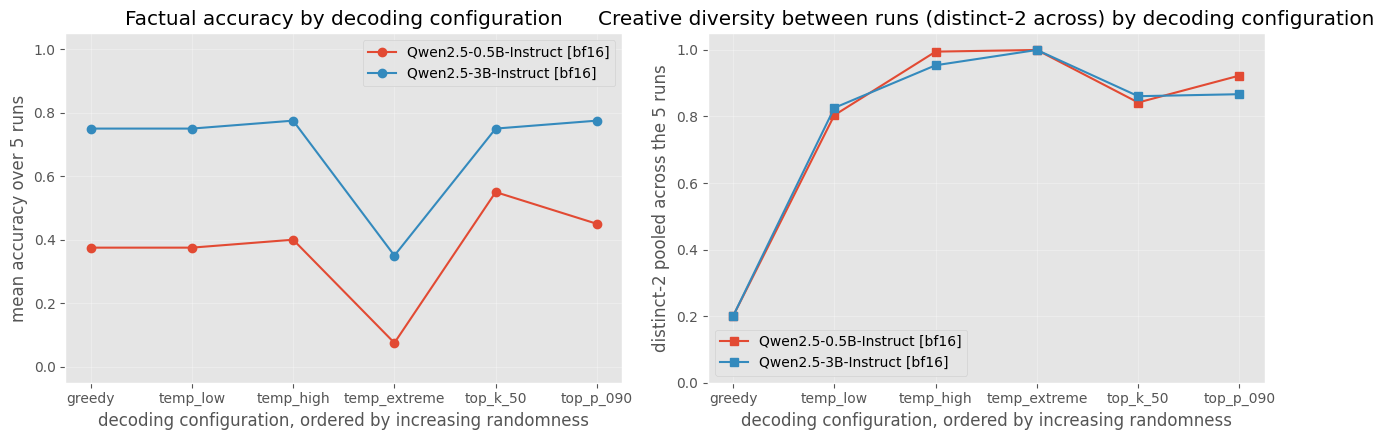

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for model_label in factual_summary["model"].unique():
    sub = factual_summary[factual_summary["model"] == model_label].sort_values("config")
    axes[0].plot(sub["config"], sub["accuracy"], marker="o", label=model_label)
axes[0].set_title("Factual accuracy by decoding configuration")
axes[0].set_xlabel("decoding configuration, ordered by increasing randomness")
axes[0].set_ylabel("mean accuracy over 5 runs")
axes[0].set_ylim(-0.05, 1.05)
axes[0].legend()
axes[0].grid(alpha=0.3)

for model_label in creative_summary["model"].unique():
    sub = creative_summary[creative_summary["model"] == model_label].sort_values("config")
    axes[1].plot(sub["config"], sub["distinct_2_across"], marker="s", label=model_label)
axes[1].set_title("Creative diversity between runs (distinct-2 across) by decoding configuration")
axes[1].set_xlabel("decoding configuration, ordered by increasing randomness")
axes[1].set_ylabel("distinct-2 pooled across the 5 runs")
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שני הגרפים אומרים דברים הפוכים על אותו ציר:</p>
<ul>
<li>בגרף השמאלי הקווים נפרדים לכל האורך, והפער הוא גודל המודל. הצורה זהה — הדקודינג קובע את צורת העקומה, המודל את גובהה</li>
<li>בגרף הימני הקווים כמעט חופפים. הגיוון בין ההרצות הוא תכונה של הדגימה ולא של גודל המודל — 3B אינו מגוון יותר, רק נכון יותר</li>
<li>עליית הגיוון אינה מונוטונית: אחרי השיא ב-2.0 התצורות החותכות יורדות ל-0.84–0.92. תפקידן לקצץ את הזנב שממנו מגיע הגיוון, ואיתו הרעש</li>
<li>נקודת החיתוך היא top-k ו-top-p: הן מחזירות את הדיוק לרמת greedy ושומרות גיוון גבוה. temp_extreme משיג 1.000 במחיר דיוק שקורס</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ממצאים ומסקנות — חלק ב׳:</p>
<ul>
<li>הטרייד-אוף נמדד: ב-2.0 הדיוק צנח ל-0.075 ול-0.350 ו-distinct-2 עלה ל-1.000. הגיוון המקסימלי הושג בנקודה שבה התוכן קרס</li>
<li>עקביות אינה דיוק: ב-capital_aus הקטן החזיר "Sydney" בכל חמש הרצות ה-greedy — עקביות 1.0 ודיוק 0.00. אותה טעות, חמש פעמים</li>
<li>הקשר למנגנון: טמפרטורה משנה חדות ולא דירוג. בעובדתי ההתפלגות מרוכזת וחימום דוגם זנב שגוי; בפתוח הזנב הוא מקור הגיוון</li>
<li>לכן הדגימה עוזרת דווקא לקטן: top-k מעלה מ-0.375 ל-0.550, כי הנכונה קיימת אך אינה השכיחה. אצל הגדול הכול שטוח — עקבי עם התפלגות חדה יותר</li>
<li>הגדול עמיד יותר: ב-2.0 הוא מחזיק 0.350 מול 0.075 — אותו prompt, אותה טמפרטורה; ההבדל ככל הנראה בחדות ההתפלגות</li>
<li>מה לא ניתן להסיק: שמונה משימות עובדתיות ומשימה יצירתית אחת. רזולוציית המדידה 0.025 והשונות הבינומית כ-0.08, ולכן אלה מגמות ולא אומדנים</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>חלק ג׳ — הקשר, מיקום וזיכרון</p>
<p>מטרת החלק: לבדוק כיצד אורך ההקשר ומיקום המידע בתוכו משפיעים על היכולת להשתמש בו.</p>
<p>מסמך סינתטי מכיל קוד פרויקט בתחילתו, באמצעו או בסופו, ושאר התוכן זהה. ארבעה אורכים עד 30 אלף טוקנים, ונמדדים אחזור, זמן וטוקנים.</p>
<p>שתי החלטות תכנון מבודדות את המיקום כגורם היחיד:</p>
<ul>
<li>הפענוח greedy בלבד — בדגימה כל כישלון אחזור היה יכול לנבוע מהגרלה ולא מהמיקום</li>
<li>המילוי בנוי ממשפטים ממוספרים וחוזרים, כך שהמסמך גדל באורך ולא בקושי סמנטי</li>
</ul>
<p>בדיקת lost in the middle עם עובדות מתחרות רצה בנפרד: אותו מסמך מקבל שמונה קודים מסיחים, והשאלה מבקשת את הקוד של תווית מסוימת.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הגדרת המטרה והמסיחים:</p>
<ul>
<li>שמונת המסיחים נבחרו כהחמצות-כמעט — חלקם חולקים תחילית או ספרות עם המטרה, ושניים מהם נבדלים ממנה בשני תווים בלבד — כך שמודל שמתאים תבנית יבחר בשגוי</li>
<li>המילוי נושא קודים משלו, אחד לכל משפט שלישי בערך, כך שמסמך של 30K מכיל כמה מאות קודים מתחרים ואיתור ORION הוא חיפוש אמיתי</li>
<li>הקודים נבנים דטרמיניסטית משמות הקבוצות, וכל התנגשות עם המטרה או עם המסיחים מסוננת מראש</li>
</ul>
<p>בפיילוט המילוי היה משפט חוזר יחיד, המטרה נראתה שונה מכל השאר, והאחזור הצליח בכל מיקום ואורך — טבלה של אמת בלבד, בלי מה לנתח.</p>
</div>

In [ ]:
TARGET_LABEL = "PROJECT ORION"
TARGET_CODE = "ORN-7719-QX"

DISTRACTOR_CODES = [("PROJECT ORPHEUS", "ORP-7719-QZ"),
                    ("PROJECT ORACLE",  "ORC-7791-QX"),
                    ("PROJECT VEGA",    "VGA-3312-KL"),
                    ("PROJECT LYRA",    "LYR-8804-MN"),
                    ("PROJECT DRACO",   "DRC-2251-TP"),
                    ("PROJECT CETUS",   "CTS-6690-RW"),
                    ("PROJECT AURIGA",  "ARG-9143-BV"),
                    ("PROJECT HYDRA",   "HYD-4408-JD")]

OPS_SENTENCE = ("Internal operations note {n}: the quarterly logistics review confirmed that "
                "routine maintenance windows remain unchanged and that no additional approvals "
                "are required for standard procurement requests during this period. ")

FILLER_NAMES = ["AQUILA", "BOOTES", "CARINA", "DORADO", "ERIDANUS", "FORNAX", "GRUS",
                "HYDRUS", "INDUS", "LACERTA", "MENSA", "NORMA", "OCTANS", "PAVO",
                "PYXIS", "RETICULUM", "SCULPTOR", "TUCANA", "VELA", "VOLANS",
                "ANTLIA", "CAELUM", "CIRCINUS", "COLUMBA", "CRATER", "EQUULEUS",
                "LEPUS", "LYNX", "MICROSCOPIUM", "MONOCEROS", "PICTOR", "SAGITTA",
                "SCUTUM", "SEXTANS", "TELESCOPIUM", "TRIANGULUM", "VULPECULA", "APUS"]

FILLER_PROJECTS = [
    (f"PROJECT {name}", f"{name[:3]}-{1000 + (i * 373) % 8900}-{chr(65 + i % 26)}{chr(90 - i % 26)}")
    for i, name in enumerate(FILLER_NAMES)
]
_taken = {TARGET_CODE} | {c for _, c in DISTRACTOR_CODES}
FILLER_PROJECTS = [(n, c) for n, c in FILLER_PROJECTS if c not in _taken]

print(f"target: {TARGET_LABEL} -> {TARGET_CODE}")
print(f"explicit near-miss distractors: {len(DISTRACTOR_CODES)}")
print(f"filler projects competing for attention: {len(FILLER_PROJECTS)}")
print("sample filler codes:", [c for _, c in FILLER_PROJECTS[:5]])

target: PROJECT ORION -> ORN-7719-QX
explicit near-miss distractors: 8
filler projects competing for attention: 38
sample filler codes: ['AQU-1000-AZ', 'BOO-1373-BY', 'CAR-1746-CX', 'DOR-2119-DW', 'ERI-2492-EV']


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>38 מתוך 38 שמות המילוי שרדו את הסינון, כלומר לא נוצרה אף התנגשות עם המטרה או עם המסיחים. הקודים לדוגמה מראים שהתבנית אחידה ולכן המטרה אינה בולטת לעין.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה build_filler בונה מילוי שאינו אינרטי: כל משפט שלישי נושא קוד גישה של פרויקט אחר, כך שמשפט המטרה אינו היחיד מסוגו במסמך.</p>
</div>

In [ ]:
def build_filler(n_sentences, start_index=0):
    parts = []
    for i in range(n_sentences):
        k = start_index + i
        if k % 3 == 2:
            name, code = FILLER_PROJECTS[k % len(FILLER_PROJECTS)]
            parts.append(f"The access code for {name} is {code}. ")
        else:
            parts.append(OPS_SENTENCE.format(n=k))
    return "".join(parts)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה build_document משבצת את המטרה ב-2%, 50% או 98%, כדי שלא תיפול על גבול ה-prompt. האורך נמדד על שלושה משפטים.</p>
</div>

In [ ]:
def build_document(tok, target_tokens, position, with_distractors=False):
    fact = f"The access code for {TARGET_LABEL} is {TARGET_CODE}. "
    probe_len = max(len(encode_ids(tok, build_filler(3, 0))) / 3.0, 1.0)
    total = max(int(target_tokens / probe_len), 8)

    slots = {"start": 0.02, "middle": 0.50, "end": 0.98}
    inserts = [(slots[position], fact)]
    if with_distractors:
        spread = [0.08, 0.20, 0.32, 0.42, 0.60, 0.72, 0.84, 0.94]
        for (label, code_value), frac in zip(DISTRACTOR_CODES, spread):
            inserts.append((frac, f"The access code for {label} is {code_value}. "))
    inserts.sort(key=lambda pair: pair[0])

    pieces, cursor = [], 0
    for frac, text in inserts:
        index = min(max(int(total * frac), 0), total)
        pieces.append(build_filler(max(index - cursor, 0), cursor))
        pieces.append(text)
        cursor = max(index, cursor)
    pieces.append(build_filler(max(total - cursor, 0), cursor))
    return "".join(pieces)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>השאלה מבקשת את הקוד בפורמט שבמסמך, כך שכישלון הוא אחזור שגוי. שלושה מיקומים בארבעה אורכים: 12 הרצות למודל ועוד 12 עם מסיחים.</p>
</div>

In [ ]:
POSITIONS = ["start", "middle", "end"]

QUESTION = (f"Read the document above. What is the access code for {TARGET_LABEL}? "
            "Reply with the code only, in the exact format shown in the document.")

print(f"target fact: {TARGET_LABEL} -> {TARGET_CODE}")
print(f"context lengths: {CONTEXT_TARGETS}")
print(f"positions: {POSITIONS}")
print(f"runs per model: {len(CONTEXT_TARGETS) * len(POSITIONS)} plus "
      f"{len(CONTEXT_TARGETS) * len(POSITIONS)} with distractors")

target fact: PROJECT ORION -> ORN-7719-QX
context lengths: [2000, 8000, 16000, 30000]
positions: ['start', 'middle', 'end']
runs per model: 12 plus 12 with distractors


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>24 הרצות לכל מודל, 48 בסך הכול.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה run_context_experiment מריצה כל שילוב אורך-מיקום ב-greedy ורושמת אחזור, בחירת מסיח, זמן, זיכרון וטוקנים; חריגה מדולגת.</p>
</div>

In [ ]:
def run_context_experiment(model, tok, model_label, with_distractors=False):
    rows = []
    total = len(CONTEXT_TARGETS) * len(POSITIONS)
    step = 0
    started = time.perf_counter()
    skipped = set()
    for target_tokens in CONTEXT_TARGETS:
        for position in POSITIONS:
            step += 1
            if target_tokens in skipped:
                continue
            document = build_document(tok, target_tokens, position, with_distractors)
            prompt = document + "\n\n" + QUESTION
            reset_peak_memory()
            try:
                out = generate_once(model, tok, prompt, max_new_tokens=24, do_sample=False)
            except torch.cuda.OutOfMemoryError:
                skipped.add(target_tokens)
                gc.collect()
                torch.cuda.empty_cache()
                rows.append({"model": model_label, "distractors": with_distractors,
                             "target_ctx": target_tokens, "input_tokens": None,
                             "position": position, "retrieved": None,
                             "picked_distractor": None, "seconds": None,
                             "peak_gib": None, "answer": "OUT OF MEMORY"})
                print(f"  [{step}/{total}] ctx={target_tokens:>6} out of memory, "
                      f"skipping this length", flush=True)
                continue
            found = TARGET_CODE.lower() in out["text"].lower()
            picked = any(cd.lower() in out["text"].lower() for _, cd in DISTRACTOR_CODES)
            rows.append({
                "model": model_label, "distractors": with_distractors,
                "target_ctx": target_tokens, "input_tokens": out["input_tokens"],
                "position": position, "retrieved": found, "picked_distractor": picked,
                "seconds": out["seconds"], "peak_gib": peak_memory_gib(),
                "answer": out["text"][:60],
            })
            if not found:
                record_failure("long_context", model_label, QUESTION, out["text"], TARGET_CODE,
                               f"position={position} ctx={out['input_tokens']} "
                               f"distractors={with_distractors}")
            gc.collect()
            torch.cuda.empty_cache()
            print(f"  [{step}/{total}] ctx={out['input_tokens']:>6} pos={position:<6} "
                  f"retrieved={found}  {time.perf_counter() - started:5.0f}s", flush=True)
    return rows

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>כל מודל רץ פעמיים — בלי מסיחים ואיתם — לפני שהוא משוחרר והבא נטען.</p>
</div>

In [ ]:
context_rows = []
for role in ["small", "large"]:
    label = MODEL_IDS[role].split("/")[-1] + " [bf16]"
    print(f"loading {label} ...")
    model, tok = load_model(MODEL_IDS[role])
    context_rows += run_context_experiment(model, tok, label, with_distractors=False)
    context_rows += run_context_experiment(model, tok, label, with_distractors=True)
    del model, tok
    free_gpu()
    print(f"done {label}")

context_df = pd.DataFrame(context_rows)
RESULTS["part_c_raw"] = context_df.to_dict("records")
print()
print(context_df.to_string(index=False))

loading Qwen2.5-0.5B-Instruct [bf16] ...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

  [1/12] ctx=  2130 pos=start  retrieved=True      1s
  [2/12] ctx=  2130 pos=middle retrieved=True      1s
  [3/12] ctx=  2130 pos=end    retrieved=True      2s
  [4/12] ctx=  8439 pos=start  retrieved=True      3s
  [5/12] ctx=  8439 pos=middle retrieved=False      3s
  [6/12] ctx=  8439 pos=end    retrieved=True      4s
  [7/12] ctx= 16898 pos=start  retrieved=True      6s
  [8/12] ctx= 16898 pos=middle retrieved=False      7s
  [9/12] ctx= 16898 pos=end    retrieved=True      8s
  [10/12] ctx= 31762 pos=start  retrieved=False     10s
  [11/12] ctx= 31762 pos=middle retrieved=False     12s
  [12/12] ctx= 31762 pos=end    retrieved=True     15s
  [1/12] ctx=  2278 pos=start  retrieved=True      1s
  [2/12] ctx=  2278 pos=middle retrieved=True      1s
  [3/12] ctx=  2278 pos=end    retrieved=True      2s
  [4/12] ctx=  8587 pos=start  retrieved=True      3s
  [5/12] ctx=  8587 pos=middle retrieved=False      3s
  [6/12] ctx=  8587 pos=end    retrieved=True      4s
  [7/12] ctx= 17046 

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

  [1/12] ctx=  2130 pos=start  retrieved=True      1s
  [2/12] ctx=  2130 pos=middle retrieved=True      2s
  [3/12] ctx=  2130 pos=end    retrieved=True      3s
  [4/12] ctx=  8439 pos=start  retrieved=True      5s
  [5/12] ctx=  8439 pos=middle retrieved=True      8s
  [6/12] ctx=  8439 pos=end    retrieved=True     10s
  [7/12] ctx= 16898 pos=start  retrieved=True     15s
  [8/12] ctx= 16898 pos=middle retrieved=True     19s
  [9/12] ctx= 16898 pos=end    retrieved=True     24s
  [10/12] ctx= 31762 pos=start  retrieved=False     32s
  [11/12] ctx= 31762 pos=middle retrieved=False     41s
  [12/12] ctx= 31762 pos=end    retrieved=True     50s
  [1/12] ctx=  2278 pos=start  retrieved=True      1s
  [2/12] ctx=  2278 pos=middle retrieved=True      2s
  [3/12] ctx=  2278 pos=end    retrieved=True      3s
  [4/12] ctx=  8587 pos=start  retrieved=True      5s
  [5/12] ctx=  8587 pos=middle retrieved=True      8s
  [6/12] ctx=  8587 pos=end    retrieved=True     11s
  [7/12] ctx= 17046 pos

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שישה ממצאים מ-48 ההרצות:</p>
<ul>
<li>הסוף שורד תמיד: 16 מתוך 16 ההרצות עם העובדה בסוף אחזרו נכון, בשני המודלים ובכל האורכים. העדכניות מבטלת את השפעת האורך</li>
<li>lost in the middle מופיע בסף שונה לכל גודל: הקטן מאבד את האמצע ב-8K והגדול ב-30K. הגודל אינו מבטל את התופעה, רק דוחה אותה</li>
<li>ב-30K נשבר גם ההתחלה: שני המודלים נכשלים ב-start, כלומר ההידרדרות אינה רק באמצע אלא בכל מה שאינו סמוך לשאלה</li>
<li>הכישלונות אינם ריקים אלא שגויים בביטחון: הקטן מחזיר CAR-1746-CX — קוד מילוי אמיתי מהמסמך — ובמקרה אחר "7719-QX", ספרות נכונות עם תחילית חסרה. הגדול ב-30K מעתיק משפט מילוי שלם במקום לענות</li>
<li>המסיח כמעט-זהה עבד פעם אחת מתוך 24 ההרצות עם מסיחים, וזה מספיק: הגדול ב-30K ב-start החזיר ORP-7719-QZ — אותן ספרות, תחילית שונה בתו אחד — במקום להודות שלא מצא. שאר ההרצות לא נגעו במסיחים, כי קודי המילוי כבר שימשו מסיחים בפועל</li>
<li>העלות נפרשת אחרת: פי 15 טוקנים מייקרים את הקטן פי 6.3 ואת הגדול פי 13.2, והזיכרון ב-1.35 מול 3.31 GiB — שיא הזיכרון כולל את מטמון ה-KV ואת מבני ה-prefill</li>
</ul>
<p>הערה: ב-30K באמצע הגדול הצליח דווקא בגרסה עם המסיחים ונכשל בלעדיהם. שני המסמכים אינם זהים — 31,910 מול 31,762 טוקנים — ולכן העובדה נופלת במיקום מעט אחר. זו אינדיקציה לכך שבקצה החלון האחזור שביר ותלוי-מיקום ברזולוציה של עשרות טוקנים.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שלוש מטריצות מיקום מול אורך: אחזור בלי מסיחים, אחזור איתם, ובחירת מסיח. הפרדת השלישית מבחינה בין כישלון אחזור לבחירה שגויה.</p>
<p>טבלה רביעית מסכמת את העלות — טוקני קלט, זמן ושיא זיכרון לכל אורך. אורכים שלא נכנסו לכרטיס מדווחים ומוסרים מהמיצוע.</p>
</div>

In [ ]:
measured = context_df[context_df["retrieved"].notna()]
if len(measured) < len(context_df):
    dropped = sorted(context_df[context_df["retrieved"].isna()]["target_ctx"].unique())
    print(f"note: context lengths that did not fit on this card: {dropped}")
    print()

clean = measured[~measured["distractors"]]
noisy = measured[measured["distractors"]]

retrieval_matrix = clean.pivot_table(index=["model", "position"], columns="target_ctx",
                                     values="retrieved", aggfunc="first")
noisy_matrix = noisy.pivot_table(index=["model", "position"], columns="target_ctx",
                                 values="retrieved", aggfunc="first")
distractor_matrix = noisy.pivot_table(index=["model", "position"], columns="target_ctx",
                                      values="picked_distractor", aggfunc="first")

print("RETRIEVAL WITHOUT DISTRACTORS (True means the target code was returned)")
print(retrieval_matrix.to_string())
print()
print("RETRIEVAL WITH COMPETING FACTS")
print(noisy_matrix.to_string())
print()
print("PICKED A DISTRACTOR CODE INSTEAD")
print(distractor_matrix.to_string())
print()

latency = clean.groupby(["model", "target_ctx"]).agg(
    input_tokens=("input_tokens", "mean"),
    seconds=("seconds", "mean"),
    peak_gib=("peak_gib", "max")).round(3).reset_index()
print("INFERENCE COST BY CONTEXT LENGTH")
print(latency.to_string(index=False))

RESULTS["part_c_retrieval_clean"] = retrieval_matrix.to_dict()
RESULTS["part_c_retrieval_noisy"] = noisy_matrix.to_dict()
RESULTS["part_c_distractor_picks"] = distractor_matrix.to_dict()
RESULTS["part_c_latency"] = latency.to_dict("records")

RETRIEVAL WITHOUT DISTRACTORS (True means the target code was returned)
target_ctx                             2000   8000   16000  30000
model                        position                            
Qwen2.5-0.5B-Instruct [bf16] end        True   True   True   True
                             middle     True  False  False  False
                             start      True   True   True  False
Qwen2.5-3B-Instruct [bf16]   end        True   True   True   True
                             middle     True   True   True  False
                             start      True   True   True  False

RETRIEVAL WITH COMPETING FACTS
target_ctx                             2000   8000   16000  30000
model                        position                            
Qwen2.5-0.5B-Instruct [bf16] end        True   True   True   True
                             middle     True  False  False  False
                             start      True   True   True  False
Qwen2.5-3B-Instruct [bf16]   end      

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>המטריצות הופכות את התבנית לחדה:</p>
<ul>
<li>שורת ה-end אמת בכל שמונה התאים, בעוד start ו-middle נשברות. ברזולוציה של ארבעה אורכים המבנה נראה כמדרגה: כל מיקום מחזיק עד סף ונופל</li>
<li>שמונת המסיחים המפורשים כמעט אינם משנים — שתי המטריצות הראשונות זהות למעט תא אחד — כי המילוי עצמו כבר נושא מאות קודים מתחרים בשתי הגרסאות. הקושי מגיע מהאורך ומהמיקום על רקע התחרות הזאת</li>
<li>בחירת מסיח קרתה פעם אחת מתוך 24, במודל הגדול בתנאי הקיצון. ברוב הכישלונות המודל מחזיר קוד מילוי, שבר של הקוד או משפט מועתק — ולא אחד משמונת המסיחים המפורשים</li>
<li>העלות מתנהגת אחרת בשני הגדלים: פי 14.9 טוקנים מייקרים את הקטן פי 6.3 בלבד ואת הגדול פי 13.2, כמעט לינארי. הזיכרון עולה ב-1.35 GiB מול 3.31 — רובו מבני ה-prefill ומטמון ה-KV, שגדלים עם מספר השכבות והראשים</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>אחזור דו-שלבי: השאלה נוקבת בתפקיד ולא בשם, ולכן המודל קושר תפקיד לאדם ואז לתג. שמונה תגים מתחרים מונעים פתרון בתבנית.</p>
</div>

In [ ]:
HOP_ROLE = "site supervisor for the northern facility"
HOP_PERSON = "Dana Rivlin"
HOP_BADGE = "4417"

HOP_DISTRACTORS = [("Noa Bergman", "2298"), ("Amir Tal", "6135"), ("Yael Shani", "8072"),
                   ("Ronen Katz", "3560"), ("Lior Ashkenazi", "9184"), ("Maya Peled", "5726"),
                   ("Gil Harel", "1493"), ("Tamar Vider", "7051")]

HOP_QUESTION = ("Read the document above. Which badge number belongs to the person who "
                "supervises the northern facility? Reply with the number only.")

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה build_multihop_document מקבעת את עובדת התפקיד ב-2% ומזיזה רק את התג, כך שהנמדד הוא מרחק החוליה השנייה מהראשונה.</p>
</div>

In [ ]:
def build_multihop_document(tok, target_tokens, position):
    probe_len = max(len(encode_ids(tok, build_filler(3, 0))) / 3.0, 1.0)
    total = max(int(target_tokens / probe_len), 8)

    role_fact = f"The {HOP_ROLE} is {HOP_PERSON}. "
    badge_fact = f"{HOP_PERSON} was issued badge number {HOP_BADGE}. "
    slots = {"start": 0.12, "middle": 0.50, "end": 0.96}

    inserts = [(0.02, role_fact), (slots[position], badge_fact)]
    spread = [0.08, 0.20, 0.32, 0.44, 0.58, 0.70, 0.82, 0.92]
    for (name, badge), frac in zip(HOP_DISTRACTORS, spread):
        inserts.append((frac, f"{name} was issued badge number {badge}. "))
    inserts.sort(key=lambda pair: pair[0])

    pieces, cursor = [], 0
    for frac, text in inserts:
        index = min(max(int(total * frac), 0), total)
        pieces.append(build_filler(max(index - cursor, 0), cursor))
        pieces.append(text)
        cursor = max(index, cursor)
    pieces.append(build_filler(max(total - cursor, 0), cursor))
    return "".join(pieces)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה run_multihop_experiment מריצה את אותה מטריצת אורך-מיקום, ובודקת אם התג הנכון מופיע בתשובה ואם נבחר תג של אדם אחר.</p>
</div>

In [ ]:
def run_multihop_experiment(model, tok, model_label):
    rows = []
    started = time.perf_counter()
    for target_tokens in CONTEXT_TARGETS:
        for position in POSITIONS:
            document = build_multihop_document(tok, target_tokens, position)
            prompt = document + "\n\n" + HOP_QUESTION
            out = generate_once(model, tok, prompt, max_new_tokens=24, do_sample=False)
            answer = normalize_answer(out["text"])
            correct = HOP_BADGE in answer.split()
            picked_other = any(badge in answer.split() for _, badge in HOP_DISTRACTORS)
            rows.append({
                "model": model_label, "target_ctx": target_tokens, "position": position,
                "input_tokens": out["input_tokens"], "retrieved": correct,
                "picked_distractor": picked_other, "seconds": out["seconds"],
                "answer": out["text"][:60],
            })
            if not correct:
                record_failure("long_context_multihop", model_label, HOP_QUESTION,
                               out["text"], HOP_BADGE,
                               f"badge fact at {position}, ctx={out['input_tokens']}")
            gc.collect()
            torch.cuda.empty_cache()
            print(f"  [multihop] ctx={out['input_tokens']:>6} pos={position:<6} "
                  f"correct={correct}  {time.perf_counter() - started:5.0f}s", flush=True)
    return rows

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הרצת הבדיקה הרב-שלבית על שני המודלים, ובסוף מטריצת אחזור לפי מיקום החוליה השנייה.</p>
</div>

In [ ]:
multihop_rows = []
for role in ["small", "large"]:
    label = MODEL_IDS[role].split("/")[-1] + " [bf16]"
    print(f"loading {label} for the multi-hop probe ...")
    model, tok = load_model(MODEL_IDS[role])
    multihop_rows += run_multihop_experiment(model, tok, label)
    del model, tok
    free_gpu()

multihop_df = pd.DataFrame(multihop_rows)
RESULTS["part_c_multihop"] = multihop_df.to_dict("records")
print()
print(multihop_df.to_string(index=False))
print()
print("MULTI-HOP RETRIEVAL BY POSITION OF THE SECOND FACT")
print(multihop_df.pivot_table(index=["model", "position"], columns="target_ctx",
                              values="retrieved", aggfunc="first").to_string())

loading Qwen2.5-0.5B-Instruct [bf16] for the multi-hop probe ...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

  [multihop] ctx=  2240 pos=start  correct=True      0s
  [multihop] ctx=  2240 pos=middle correct=True      1s
  [multihop] ctx=  2240 pos=end    correct=True      1s
  [multihop] ctx=  8549 pos=start  correct=False      2s
  [multihop] ctx=  8549 pos=middle correct=False      3s
  [multihop] ctx=  8549 pos=end    correct=True      4s
  [multihop] ctx= 17008 pos=start  correct=False      5s
  [multihop] ctx= 17008 pos=middle correct=False      6s
  [multihop] ctx= 17008 pos=end    correct=True      7s
  [multihop] ctx= 31872 pos=start  correct=False      9s
  [multihop] ctx= 31872 pos=middle correct=False     11s
  [multihop] ctx= 31872 pos=end    correct=True     14s
loading Qwen2.5-3B-Instruct [bf16] for the multi-hop probe ...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

  [multihop] ctx=  2240 pos=start  correct=True      1s
  [multihop] ctx=  2240 pos=middle correct=True      2s
  [multihop] ctx=  2240 pos=end    correct=True      2s
  [multihop] ctx=  8549 pos=start  correct=True      4s
  [multihop] ctx=  8549 pos=middle correct=True      6s
  [multihop] ctx=  8549 pos=end    correct=True      8s
  [multihop] ctx= 17008 pos=start  correct=True     12s
  [multihop] ctx= 17008 pos=middle correct=True     16s
  [multihop] ctx= 17008 pos=end    correct=True     20s
  [multihop] ctx= 31872 pos=start  correct=True     28s
  [multihop] ctx= 31872 pos=middle correct=False     36s
  [multihop] ctx= 31872 pos=end    correct=True     44s

                       model  target_ctx position  input_tokens  retrieved  picked_distractor  seconds answer
Qwen2.5-0.5B-Instruct [bf16]        2000    start          2240       True              False   0.1637   4417
Qwen2.5-0.5B-Instruct [bf16]        2000   middle          2240       True              False   0.1625   4

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הקישור הדו-שלבי משנה את התמונה:</p>
<ul>
<li>הקטן קורס מוקדם: ב-8K הוא נכשל ב-start וב-middle, בעוד באחזור החד-שלבי ההתחלה שרדה עד 16K. החוליה השנייה מפילה אותו</li>
<li>הגדול כמעט לא נפגע — 11 מתוך 12 — ונכשל רק ב-30K באמצע. גודל המודל קונה כאן הרבה יותר מאשר באחזור פשוט</li>
<li>הכשל הופך מדממה לבחירה שגויה: 5 מתוך 24 בחרו תג של אדם אחר, מול 1 מתוך 48 קודם. מי שאינו מקשר לוקח מספר תקין כלשהו</li>
<li>הבחירות אינן אקראיות: הקטן לוקח את 7051 ו-1493, התגים האחרונים לפני השאלה, והגדול את 2298 הראשון במסמך — עדכניות מול ראשוניות</li>
<li>ב-30K הקטן מתפרק לגמרי ומחזיר "7" ו-"78": לא תג שגוי אלא שבר של מספר. מהפלט לבדו אי אפשר להכריע אם זה כשל אחזור או כשל ייצור</li>
<li>ב-30K הגדול הצליח דווקא ב-start, שם נכשל באחזור החד-שלבי. החוליות יושבות ב-2% וב-12% — תא בודד, אך עקבי עם השערה שהקרבה בין החוליות חשובה מהמרחק מהשאלה</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שלושה גרפים:</p>
<ul>
<li>שיעור אחזור לכל אחת משלוש הבדיקות, כשכל תנאי המיקום והאורך מקובצים ומספר הפגיעות רשום מעל כל עמודה</li>
<li>זמן הסקה כפונקציה של אורך הקלט</li>
<li>גידול הזיכרון מעל 2K, כהפרש כדי שהמשקלים לא יסתירו את מטמון ה-KV. פער מול חלק ה׳ אינו שגיאה: גדלים גם מבני הביניים של ה-prefill</li>
</ul>
</div>

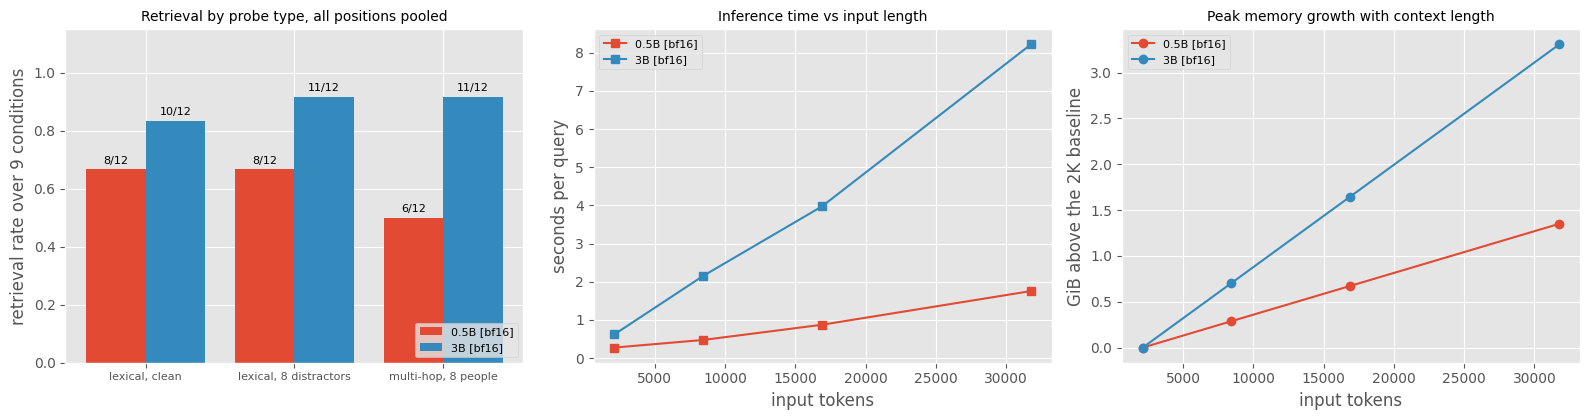

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))

probes = [("lexical, clean", clean), ("lexical, 8 distractors", noisy),
          ("multi-hop, 8 people", multihop_df)]
model_labels = list(context_df["model"].unique())
width = 0.8 / len(model_labels)
x = np.arange(len(probes))

for m_index, model_label in enumerate(model_labels):
    rates, counts = [], []
    for _, frame in probes:
        sub = frame[frame["model"] == model_label]
        rates.append(sub["retrieved"].mean())
        counts.append(f"{int(sub['retrieved'].sum())}/{len(sub)}")
    bars = axes[0].bar(x + m_index * width, rates, width,
                       label=model_label.replace("Qwen2.5-", "").replace("-Instruct", ""))
    for bar, count in zip(bars, counts):
        axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                     count, ha="center", fontsize=8)
axes[0].set_xticks(x + width * (len(model_labels) - 1) / 2)
axes[0].set_xticklabels([name for name, _ in probes], fontsize=8)
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel("retrieval rate over 9 conditions")
axes[0].set_title("Retrieval by probe type, all positions pooled", fontsize=10)
axes[0].legend(fontsize=8, loc="lower right")

for model_label in latency["model"].unique():
    sub = latency[latency["model"] == model_label]
    axes[1].plot(sub["input_tokens"], sub["seconds"], marker="s",
                 label=model_label.replace("Qwen2.5-", "").replace("-Instruct", ""))
axes[1].set_title("Inference time vs input length", fontsize=10)
axes[1].set_xlabel("input tokens")
axes[1].set_ylabel("seconds per query")
axes[1].legend(fontsize=8)

for model_label in latency["model"].unique():
    sub = latency[latency["model"] == model_label]
    base = sub["peak_gib"].iloc[0]
    axes[2].plot(sub["input_tokens"], sub["peak_gib"] - base, marker="o",
                 label=model_label.replace("Qwen2.5-", "").replace("-Instruct", ""))
axes[2].set_title("Peak memory growth with context length", fontsize=10)
axes[2].set_xlabel("input tokens")
axes[2].set_ylabel("GiB above the 2K baseline")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ארבעה דברים שרואים רק בגרפים:</p>
<ul>
<li>הקושי אינו סימטרי: הקישור הדו-שלבי מוריד את הקטן מ-8/12 ל-6/12, ואת הגדול לא מוריד כלל. "משימה קשה יותר" תלוי בגודל</li>
<li>המסיחים דווקא העלו את הגדול מ-10/12 ל-11/12. זו אינה עמידות אלא רעש: אותו תא ב-30K שהשתנה בין המסמכים</li>
<li>שני הגרפים הימניים ישרים ולא קמורים. הקשב ריבועי באורך, אך עד 30K הריבועיות עוד לא נראית בזמן הכולל — עקבי עם צוואר בקבוק לינארי כמו רוחב פס, שלא נמדד ישירות</li>
<li>פער הזמן מתרחב עם האורך: פי 2.2 ב-2K ופי 4.7 ב-30K. הזיכרון גדל פי 2.45, בין יחס השכבות (1.5) ליחס נפח המטמון לפי הקונפיגורציה (3.0)</li>
</ul>
<p>הערת תיוג: ציר ה-y בגרף השמאלי נושא את הכיתוב 9 תנאים, אך כל עמודה מסכמת 12 — ארבעה אורכים בשלושה מיקומים — כפי שמופיע בספרות מעל העמודות.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ממצאים ומסקנות — חלק ג׳:</p>
<ul>
<li>מיקום: הסוף שרד ב-24 מתוך 24 בשלוש הבדיקות יחד, האמצע וההתחלה נשברו. העדיפות לקצה קיימת, אך רק לקצה הסמוך לשאלה</li>
<li>אורך: האחזור מלא רק ב-2K בקטן ועד 16K בגדול, וקורס ב-30K בשניהם. ברזולוציה שנבדקה ההידרדרות נראית כסף</li>
<li>מסיחים: שמונה קודים דומים כמעט לא שינו, כי המילוי כבר נשא מאות. הכשל התבטא באי-אחזור, ובמקרה אחד בבחירת מסיח</li>
<li>קישור דו-שלבי: קשה יותר לקטן בלבד — 6/12 מול 8/12 — ואצל הגדול זהה. שם הכשל הופך לבחירת תג של אדם אחר, 5 מתוך 24</li>
<li>עלות: הזמן והזיכרון גדלים לינארית, פי 6.3 ופי 13.2 בזמן על פני פי 14.9 טוקנים. העקומה הריבועית של הקשב עוד לא נראית</li>
<li>מה לא ניתן להסיק: הניסוי מודד קלט-פלט. כשל באמצע אינו מוכיח דבר על RoPE, ויכול לנבוע מנתוני האימון. המנגנון דורש גישה פנימית</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>חלק ד׳ — סקיילינג: מה משתנה כשמגדילים את המודל</p>
<p>מטרת החלק: להשוות שלושה גדלים של אותה משפחה, איכות מול עלות.</p>
<p>ה-benchmark מונה 24 פריטים בארבעה סוגי משימה, שישה בכל סוג, וכל סוג נמדד אחרת:</p>
<ul>
<li>עמידה בהוראות — אילוץ פורמט מדיד, נבדק בביטוי רגולרי</li>
<li>הנמקה — בעיות רב-שלביות עם תשובה מספרית, התאמה מדויקת</li>
<li>קוד — פונקציה קצרה, נבדקת במבחני יחידה שרצים בפועל</li>
<li>עברית — תשובה קצרה, התאמה מנורמלת</li>
</ul>
<p>נמדדים גם זמן לדוגמה, שיא זיכרון וזיכרון המשקולות. הפענוח greedy בכל המשימות, כדי שההשוואה לא תזוהם באקראיות.</p>
<p>שלושת המודלים שייכים לאותה משפחה ורצים ב-bf16 עם אותו טוקנייזר ואותה תבנית שיחה. הגורם הנשלט היחיד שמשתנה הוא הגודל — בכפוף לכך שהרכב האימון של כל גודל אינו מפורסם — ושלוש נקודות מראות היכן השיפור מתמצה.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>כל פריט הוא חמישייה: מזהה, סוג, prompt, ביטוי רגולרי או תשובת זהב — שני האחרונים בלעדיים זה לזה, ולכן אחד מהם תמיד None.</p>
</div>

In [ ]:
BENCHMARK = []

BENCHMARK += [
    ("instr_1", "instruction", "List exactly three primary colors, separated by commas, with no other text.",
     r"^[^,]+,[^,]+,[^,]+$", None),
    ("instr_2", "instruction", "Reply with exactly one word: the opposite of 'hot'.",
     r"^\w+$", None),
    ("instr_3", "instruction", "Answer with a single digit only: how many sides does a hexagon have?",
     r"^6$", None),
    ("instr_4", "instruction", "Reply with valid JSON only, no markdown, in the form {\"answer\": <number>}: what is 12 plus 7?",
     r"^\{\s*\"answer\"\s*:\s*19\s*\}$", None),
    ("instr_5", "instruction", "Write the word 'DONE' in uppercase and nothing else.",
     r"^DONE$", None),
    ("instr_6", "instruction", "Reply with exactly four words describing the sky at night.",
     r"^\S+\s+\S+\s+\S+\s+\S+$", None),
]

BENCHMARK += [
    ("reason_1", "reasoning", "A shop sells pens at 3 shekels each. Dana buys 7 pens and pays with a 50 shekel note. How much change does she get? Reply with the number only.", None, "29"),
    ("reason_2", "reasoning", "A train leaves at 14:20 and the journey takes 95 minutes. At what time does it arrive? Reply in HH:MM only.", None, "15:55"),
    ("reason_3", "reasoning", "If 5 machines produce 5 widgets in 5 minutes, how many minutes do 100 machines need to produce 100 widgets? Reply with the number only.", None, "5"),
    ("reason_4", "reasoning", "A rectangle has perimeter 36 and one side of length 10. What is the area? Reply with the number only.", None, "80"),
    ("reason_5", "reasoning", "Yossi is twice as old as Rina. In 6 years their combined age will be 42. How old is Rina now? Reply with the number only.", None, "10"),
    ("reason_6", "reasoning", "A book has 240 pages. You read 15 pages a day for 8 days, then 25 pages a day. How many more days until you finish? Reply with the number only.", None, "5"),
]

BENCHMARK += [
    ("code_1", "code", "Write a Python function named solve(n) that returns the sum of integers from 1 to n inclusive. Reply with code only, no explanation and no markdown fences.",
     None, [(5, 15), (1, 1), (10, 55)]),
    ("code_2", "code", "Write a Python function named solve(s) that returns the input string reversed. Reply with code only, no explanation and no markdown fences.",
     None, [("abc", "cba"), ("", ""), ("ab", "ba")]),
    ("code_3", "code", "Write a Python function named solve(xs) that returns the number of even integers in the list xs. Reply with code only, no explanation and no markdown fences.",
     None, [([1, 2, 3, 4], 2), ([], 0), ([2, 4, 6], 3)]),
    ("code_4", "code", "Write a Python function named solve(n) that returns True if n is prime and False otherwise. Reply with code only, no explanation and no markdown fences.",
     None, [(7, True), (1, False), (9, False)]),
    ("code_5", "code", "Write a Python function named solve(xs) that returns the second largest distinct value in the list xs. Reply with code only, no explanation and no markdown fences.",
     None, [([1, 5, 3], 3), ([4, 4, 2], 2), ([9, 1], 1)]),
    ("code_6", "code", "Write a Python function named solve(s) that returns the number of vowels in the lowercase string s. Reply with code only, no explanation and no markdown fences.",
     None, [("hello", 2), ("xyz", 0), ("aeiou", 5)]),
]

BENCHMARK += [
    ("heb_1", "hebrew", "מהי בירת ישראל? ענה בשם העיר בלבד.", None, "ירושלים"),
    ("heb_2", "hebrew", "כמה ימים יש בשבוע? ענה במספר בלבד.", None, "7"),
    ("heb_3", "hebrew", "מהו ההפך של המילה 'גדול'? ענה במילה אחת בלבד.", None, "קטן"),
    ("heb_4", "hebrew", "השלם את הפתגם: 'אין חכם כבעל ___'. ענה במילה אחת בלבד.", None, "ניסיון"),
    ("heb_5", "hebrew", "כמה אותיות יש באלף בית העברי? ענה במספר בלבד.", None, "22"),
    ("heb_6", "hebrew", "מי כתב את הספר 'ויהי בוקר'? ענה בשם המחבר בלבד.", None, "סייד קשוע"),
]

print(f"benchmark items: {len(BENCHMARK)}")
print(pd.Series([b[1] for b in BENCHMARK]).value_counts().to_string())

benchmark items: 24
instruction    6
reasoning      6
code           6
hebrew         6


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>עשרים וארבעה פריטים, שישה בכל סוג. פריט אחד שווה 0.042 בציון הכולל ו-0.167 בציון הסוג — זו רזולוציית המדידה, וכל פער קטן ממנה אינו קיים.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה strip_code_fences מסירה גדרות markdown. ה-prompt מבקש קוד בלבד והמודלים מוסיפים אותן — הפרת פורמט, לא שגיאת קוד.</p>
</div>

In [ ]:
def strip_code_fences(text):
    cleaned = re.sub(r"^```[a-zA-Z]*\s*", "", text.strip())
    cleaned = re.sub(r"```\s*$", "", cleaned).strip()
    return cleaned

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה score_instruction בודקת התאמה מלאה לביטוי הרגולרי. הפריט נכשל אם נוספה מילה אחת מעבר לפורמט המבוקש, גם כשהתוכן נכון.</p>
</div>

In [ ]:
def score_instruction(output, pattern, _):
    return 1.0 if re.match(pattern, output.strip()) else 0.0

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה score_reasoning בודקת אם הזהב בין מספרי התשובה. מדד מקל: מספר נכון בשרשרת שגויה נספר כהצלחה, הפורמט נמדד בנפרד.</p>
</div>

In [ ]:
def score_reasoning(output, _, gold):
    numbers = re.findall(r"-?\d+(?::\d+)?(?:\.\d+)?", output)
    if not numbers:
        return 0.0
    return 1.0 if gold in numbers else 0.0

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה score_hebrew מסירה מרכאות ומאחדת רווחים, ומחפשת את הזהב כמחרוזת חלקית — כך שתשובה נכונה בתוך משפט אינה נפסלת.</p>
</div>

In [ ]:
def score_hebrew(output, _, gold):
    norm_out = " ".join(output.replace('"', "").replace("'", "").split())
    return 1.0 if gold in norm_out else 0.0

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה score_code מריצה את הקוד שהחזיר המודל ובודקת את solve על שלושה מקרים. הציון הכול-או-כלום: חריגה או כישלון מאפסים אותו.</p>
</div>

In [ ]:
def score_code(output, _, tests):
    source = strip_code_fences(output)
    namespace = {}
    try:
        exec(source, namespace)
    except Exception:
        return 0.0
    fn = namespace.get("solve")
    if not callable(fn):
        return 0.0
    for args, expected in tests:
        try:
            got = fn(args)
        except Exception:
            return 0.0
        if got != expected:
            return 0.0
    return 1.0

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>מיפוי סוג משימה לפונקציית הציון ולתקציב הטוקנים שלה. הקוד מקבל 160 טוקנים והעברית 24, כדי שהחיתוך לא ייספר ככישלון תוכן.</p>
</div>

In [ ]:
SCORERS = {"instruction": score_instruction, "reasoning": score_reasoning,
           "code": score_code, "hebrew": score_hebrew}

MAX_TOKENS = {"instruction": 32, "reasoning": 48, "code": 160, "hebrew": 24}

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה run_benchmark מריצה כל פריט ב-greedy עם תקציב הטוקנים של סוגו ומנתבת לפונקציית הציון. precision_label משמש בבונוס.</p>
</div>

In [ ]:
def run_benchmark(model, tok, model_label, precision_label):
    rows = []
    started = time.perf_counter()
    for item_id, kind, prompt, pattern, gold in BENCHMARK:
        reset_peak_memory()
        out = generate_once(model, tok, prompt,
                            max_new_tokens=MAX_TOKENS[kind], do_sample=False)
        score = SCORERS[kind](out["text"], pattern, gold)
        rows.append({
            "model": model_label, "precision": precision_label, "item": item_id,
            "kind": kind, "score": score, "seconds": out["seconds"],
            "output_tokens": out["output_tokens"], "peak_gib": peak_memory_gib(),
            "answer": out["text"][:80].replace("\n", " "),
        })
        if score == 0.0:
            category = {"instruction": "instruction_following", "reasoning": "reasoning",
                        "code": "code_generation", "hebrew": "multilingual"}[kind]
            record_failure(category, f"{model_label} [{precision_label}]", prompt,
                           out["text"], pattern if gold is None else gold,
                           f"benchmark item {item_id}")
        if len(rows) % 6 == 0:
            done = len(rows)
            mean_score = sum(r["score"] for r in rows) / done
            print(f"  [{done:>2}/{len(BENCHMARK)}] running mean={mean_score:.2f}  "
                  f"{time.perf_counter() - started:5.0f}s", flush=True)
    return rows

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>אימות שארבע פונקציות הציון נטענו.</p>
</div>

In [ ]:
print("scorers ready:", list(SCORERS))

scorers ready: ['instruction', 'reasoning', 'code', 'hebrew']


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שלושת הגדלים רצים ברצף, כל אחד משוחרר לפני הבא. נמדד גם נפח המשקולות סביב הטעינה, כדי שההשוואה תכלול עלות ולא רק איכות.</p>
</div>

In [ ]:
BENCH_RUNS = [(role, None) for role in ["small", "mid", "large"]]

bench_rows = []
LOAD_STATS = {}

for role, quant in BENCH_RUNS:
    model_id = MODEL_IDS[role]
    label = model_id.split("/")[-1]
    precision = quant or "bf16"
    print(f"loading {label} [{precision}] ...")
    reset_peak_memory()
    baseline_gib = torch.cuda.memory_allocated() / 2**30 if torch.cuda.is_available() else 0.0
    started = time.perf_counter()
    model, tok = load_model(model_id, quant=quant)
    load_seconds = round(time.perf_counter() - started, 2)
    resident_gib = round(torch.cuda.memory_allocated() / 2**30 - baseline_gib, 3) \
        if torch.cuda.is_available() else 0.0
    n_params = sum(p.numel() for p in model.parameters())
    LOAD_STATS[f"{label}|{precision}"] = {"load_seconds": load_seconds,
                                          "weights_gib": resident_gib,
                                          "parameters_billions": round(n_params / 1e9, 3)}
    print(f"  loaded in {load_seconds}s, weights {resident_gib} GiB, {n_params / 1e9:.2f}B params")
    bench_rows += run_benchmark(model, tok, label, precision)
    del model, tok
    free_gpu()
    print(f"done {label}")

bench_df = pd.DataFrame(bench_rows)
RESULTS["part_d_raw"] = bench_df.to_dict("records")
RESULTS["part_d_load_stats"] = LOAD_STATS
print()
print(bench_df.head(10).to_string(index=False))

loading Qwen2.5-0.5B-Instruct [bf16] ...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

  loaded in 2.75s, weights 0.92 GiB, 0.49B params
  [ 6/24] running mean=0.67      1s
  [12/24] running mean=0.42      6s
  [18/24] running mean=0.39     23s
  [24/24] running mean=0.33     26s
done Qwen2.5-0.5B-Instruct
loading Qwen2.5-1.5B-Instruct [bf16] ...


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

  loaded in 15.17s, weights 2.875 GiB, 1.54B params
  [ 6/24] running mean=0.67      1s
  [12/24] running mean=0.42      2s
  [18/24] running mean=0.61      8s
  [24/24] running mean=0.58     10s
done Qwen2.5-1.5B-Instruct
loading Qwen2.5-3B-Instruct [bf16] ...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

  loaded in 4.16s, weights 5.748 GiB, 3.09B params
  [ 6/24] running mean=1.00      1s
  [12/24] running mean=0.75      2s
  [18/24] running mean=0.83     12s
  [24/24] running mean=0.75     13s
done Qwen2.5-3B-Instruct

                model precision     item        kind  score  seconds  output_tokens  peak_gib                                                                           answer
Qwen2.5-0.5B-Instruct      bf16  instr_1 instruction    1.0   0.1803              6     0.932                                                                Red, Yellow, Blue
Qwen2.5-0.5B-Instruct      bf16  instr_2 instruction    1.0   0.0651              2     0.932                                                                             cold
Qwen2.5-0.5B-Instruct      bf16  instr_3 instruction    1.0   0.0606              2     0.932                                                                                6
Qwen2.5-0.5B-Instruct      bf16  instr_4 instruction    0.0   0.2293           

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ארבעה ממצאים כבר מהפלט הגולמי:</p>
<ul>
<li>נפח המשקולות תואם את התיאוריה: 0.92, 2.875 ו-5.748 GiB על 0.49, 1.54 ו-3.09 מיליארד פרמטרים — 1.88 בתים לפרמטר, כצפוי מ-bf16</li>
<li>הממוצע הרץ חושף היכן היתרון: הקטן והבינוני זהים עד פריט 12 — 0.67 ואז 0.42 — והפער נפתח בקוד, שם הבינוני קופץ ל-0.61 והקטן ל-0.39</li>
<li>instr_4 נכשל על {"answer": "19"}: המספר נכון, המרכאות מיותרות. זהו כשל פורמט טהור, ובדיוק ההפרדה שהבנצ'מרק אמור למדוד</li>
<li>reason_2 ו-reason_3 מסתיימים ב-48 טוקנים, תקרת התקציב. השרשרת נקטעה לפני התשובה, וציון 0 מערבב "לא יודע" עם "נגמרו הטוקנים"</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שתי טבלאות: איכות לפי סוג משימה, ועלות לפי מודל — זמן, אורך פלט, זיכרון ומשקולות. ההפרדה נדרשת כי השאלה היא מה קונים ובאיזה מחיר.</p>
</div>

In [ ]:
quality = (bench_df.groupby(["model", "precision", "kind"])["score"].mean()
           .unstack("kind").round(3))
quality["overall"] = bench_df.groupby(["model", "precision"])["score"].mean().round(3)

cost = (bench_df.groupby(["model", "precision"])
        .agg(mean_seconds=("seconds", "mean"),
             mean_output_tokens=("output_tokens", "mean"),
             peak_gib=("peak_gib", "max")).round(3))
cost["weights_gib"] = [LOAD_STATS.get(f"{m}|{p}", {}).get("weights_gib") for m, p in cost.index]
cost["params_b"] = [LOAD_STATS.get(f"{m}|{p}", {}).get("parameters_billions") for m, p in cost.index]

print("QUALITY BY TASK TYPE")
print(quality.to_string())
print()
print("COST PER EXAMPLE")
print(cost.to_string())

RESULTS["part_d_quality"] = quality.reset_index().to_dict("records")
RESULTS["part_d_cost"] = cost.reset_index().to_dict("records")


QUALITY BY TASK TYPE
kind                              code  hebrew  instruction  reasoning  overall
model                 precision                                                
Qwen2.5-0.5B-Instruct bf16       0.333   0.167        0.667      0.167    0.333
Qwen2.5-1.5B-Instruct bf16       1.000   0.500        0.667      0.167    0.583
Qwen2.5-3B-Instruct   bf16       1.000   0.500        1.000      0.500    0.750

COST PER EXAMPLE
                                 mean_seconds  mean_output_tokens  peak_gib  weights_gib  params_b
model                 precision                                                                   
Qwen2.5-0.5B-Instruct bf16              1.090              39.167     0.934        0.920     0.494
Qwen2.5-1.5B-Instruct bf16              0.399              11.917     2.891        2.875     1.544
Qwen2.5-3B-Instruct   bf16              0.537              12.458     5.765        5.748     3.086


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>חמישה ממצאים מהטבלאות:</p>
<ul>
<li>השיפור אינו אחיד: קוד ועברית מזנקים ב-1.5B ואז נעצרים, בעוד הוראות והנמקה תקועים עד 3B. אותה תוספת פרמטרים קונה דברים שונים</li>
<li>ההנמקה נשארת חלשה, 0.500 גם ב-3B כמו העברית, וחלק מהכישלונות הם קטיעה בתקרת 48 הטוקנים ולא חוסר יכולת</li>
<li>הזמן לדוגמה מטעה: הקטן איטי לכאורה, 1.090 מול 0.537, אך מייצר 39.2 טוקנים מול 12.5. לטוקן הסדר מתהפך: 27.8, 33.5 ו-43.1 מילישניות</li>
<li>הפטפטת עצמה היא כשל: כל השאלות ביקשו תשובה קצרה, והקטן עונה פי שלושה יותר. זה מסביר גם את ה-0.667 שלו בעמידה בהוראות</li>
<li>העלות עולה מהר מהאיכות: פי 6.25 במשקולות קונה פי 2.25 בציון. האיכות ל-GiB יורדת מ-0.362 ל-0.130 — תשואה פוחתת בבירור</li>
</ul>
<p>רזולוציית המדידה היא 0.167 לקטגוריה, ולכן כל פער של פריט בודד אינו ניתן לפירוש. הטענות כאן נשענות רק על פערים של שני פריטים ומעלה.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שלושה גרפים:</p>
<ul>
<li>ציון לפי סוג משימה, שלושת הגדלים זה לצד זה</li>
<li>הציון הכולל מול מספר הפרמטרים בסולם לוגריתמי, שבו חוק חזקה נראה כקו ישר</li>
<li>איכות מול זמן לדוגמה. הציר האופקי הוא שניות לדוגמה, ולכן הוא נושא את ההטיה של אורך התשובה שזוהתה למעלה</li>
</ul>
</div>

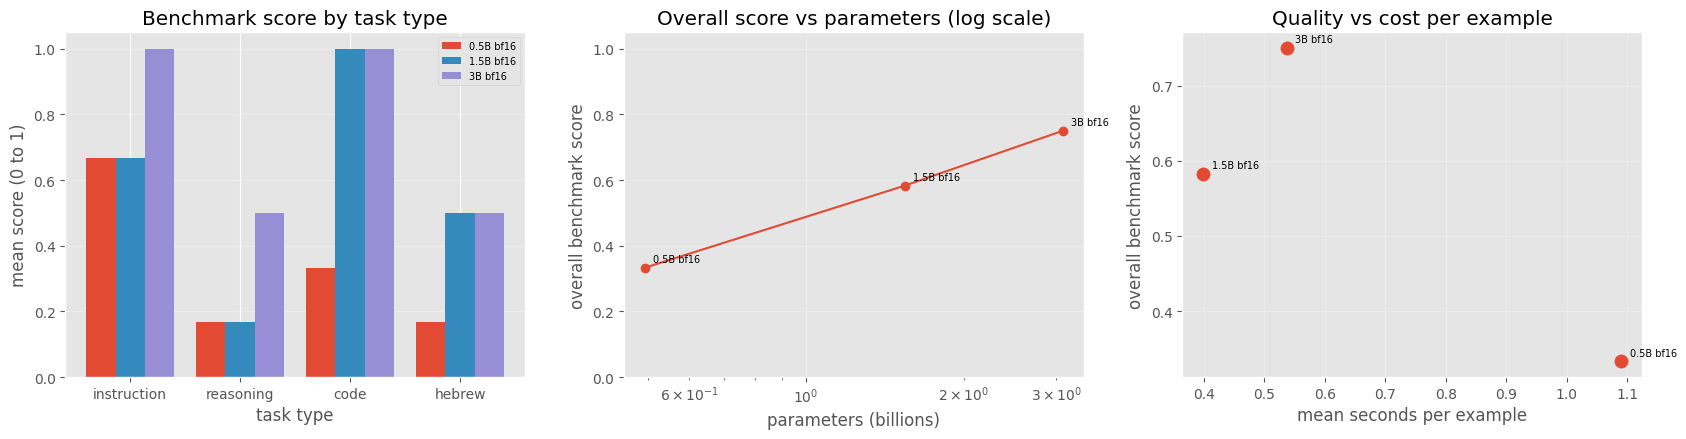

In [ ]:
combined = quality.reset_index().merge(cost.reset_index(), on=["model", "precision"])
combined = combined.sort_values("params_b")
combined["tag"] = combined["model"].str.replace("Qwen2.5-", "").str.replace("-Instruct", "") \
                  + " " + combined["precision"]

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

task_kinds = [k for k in ["instruction", "reasoning", "code", "hebrew"] if k in quality.columns]
width = 0.8 / max(len(combined), 1)
x = np.arange(len(task_kinds))
for i, (_, row) in enumerate(combined.iterrows()):
    axes[0].bar(x + i * width, [row[k] for k in task_kinds], width, label=row["tag"])
axes[0].set_xticks(x + width * (len(combined) - 1) / 2)
axes[0].set_xticklabels(task_kinds)
axes[0].set_title("Benchmark score by task type")
axes[0].set_xlabel("task type")
axes[0].set_ylabel("mean score (0 to 1)")
axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=7)
axes[0].grid(alpha=0.3, axis="y")

axes[1].plot(combined["params_b"], combined["overall"], marker="o")
for _, row in combined.iterrows():
    axes[1].annotate(row["tag"], (row["params_b"], row["overall"]),
                     textcoords="offset points", xytext=(6, 4), fontsize=7)
axes[1].set_xscale("log")
axes[1].set_title("Overall score vs parameters (log scale)")
axes[1].set_xlabel("parameters (billions)")
axes[1].set_ylabel("overall benchmark score")
axes[1].set_ylim(0, 1.05)
axes[1].grid(alpha=0.3)

axes[2].scatter(combined["mean_seconds"], combined["overall"], s=90)
for _, row in combined.iterrows():
    axes[2].annotate(row["tag"], (row["mean_seconds"], row["overall"]),
                     textcoords="offset points", xytext=(6, 4), fontsize=7)
axes[2].set_title("Quality vs cost per example")
axes[2].set_xlabel("mean seconds per example")
axes[2].set_ylabel("overall benchmark score")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שלושה דברים שהגרפים מראים:</p>
<ul>
<li>בגרף השמאלי כל משימה מזנקת במדרגה אחרת: קוד בין 0.5B ל-1.5B, הוראות והנמקה בין 1.5B ל-3B. אין משימה שמשתפרת בשתי המדרגות</li>
<li>בסולם הלוגריתמי שלוש הנקודות כמעט על קו ישר. שלוש נקודות ו-24 פריטים אינם מספיקים לקבוע חוק — זו התאמה, לא ממצא</li>
<li>בגרף הימני ה-0.5B נחות בשני הצירים ואינו על חזית פארטו. אבל הציר האופקי כולל את אורך התשובה — לטוקן בודד הוא הזול ביותר</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ממצאים ומסקנות — חלק ד׳:</p>
<ul>
<li>הפער הכולל: 0.333 ב-0.5B, 0.583 ב-1.5B ו-0.750 ב-3B. השיפור מונוטוני בציון הכולל, אך אף סוג משימה בודד אינו משתפר בשתי המדרגות</li>
<li>הציפייה התיאורטית לא התאמתה: עמידה בהוראות אמורה להיות תלוית כוונון ולא גודל, ובפועל קפצה מ-0.667 ל-1.000 במעבר ל-3B</li>
<li>רוויה מוקדמת בשניים: קוד מגיע ל-1.000 כבר ב-1.5B — וחלק ו׳ מראה שכשלי הקוד של 0.5B הם בעיקר ארטיפקט של הסרת גדרות — ועברית ל-0.500 ונעצרת. תוספת הפרמטרים מעבר לכך אינה קונה בהם דבר</li>
<li>ההנמקה נשארת חלשה, 0.500 גם בגדול, כמו העברית. חלק מהכישלונות הם קטיעה בתקרת 48 הטוקנים, ולכן זהו חסם תחתון</li>
<li>עלות מול תועלת: פי 6.25 במשקולות ופי 1.55 בזמן לטוקן — 27.8 מול 43.1 מילישניות — קונים פי 2.25 בציון. התשואה פוחתת בבירור</li>
<li>מה לא ניתן להסיק: קפלן והופמן מתארים ירידה חלקה של ה-loss, וכאן נמדד ציון על 24 פריטים. שלוש נקודות אינן מאמתות חוק סקיילינג</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>חלק ה׳ — יעילות הסקה</p>
<p>מטרת החלק: לקשור בין מטמון KV, אורך הפלט ועלות ההסקה, לבין מדידות בפועל.</p>
<p>prompt קבוע בארבעה אורכי פלט. נמדדים זמן כולל, tokens/sec וזמן עד הטוקן הראשון, ולצדם השוואה אחת עם use_cache ובלעדיו.</p>
<p>שתי תוספות מעבר לנדרש:</p>
<ul>
<li>פירוק ל-prefill ול-decode: קו ישר מותאם לארבע הנקודות, החיתוך הוא עלות ה-prefill והשיפוע עלות הפענוח לטוקן — מספר ולא תחושה</li>
<li>חישוב מטמון ה-KV מהקונפיגורציה מול המדידה, ולצדו יחס ראשי ה-query לראשי ה-KV שחושף את החיסכון של GQA</li>
</ul>
<p>הזמן עד הטוקן הראשון נמדד בהרצה נפרדת של טוקן אחד, כדי לבודד את ה-prefill בלי streaming.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ארבעה אורכי פלט למדידת השיפוע, וקצרים להשוואת ה-cache: בלעדיו כל טוקן מחשב מחדש את הקשב. ה-prompt מורחב ל-3000 טוקנים.</p>
</div>

In [ ]:
EFF_PROMPT = ("Explain in plain language how a key-value cache reduces the cost of "
              "autoregressive text generation, and why it does not reduce the cost of "
              "processing the prompt itself.")
OUTPUT_LENGTHS = [32, 64, 128, 256]
UNCACHED_LENGTHS = [8, 16, 32]
CACHE_PROBE_TOKENS = 3000

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה kv_cache_report מחלצת את מספר השכבות, ראשי ה-query וה-KV וממד הראש, שמהם מחושב נפח המטמון, ומזהה קשב מקומי.</p>
</div>

In [ ]:
def kv_cache_report(model):
    cfg = read_config_attr(model.config, "text_config", model.config)
    per_layer = read_config_attr(cfg, "per_layer_config")
    layer_types = read_config_attr(cfg, "layer_types")
    if per_layer:
        layer_cfgs = list(per_layer)
    else:
        layer_cfgs = [cfg] * int(read_config_attr(cfg, "num_hidden_layers", 0))

    layers = []
    for index, layer_cfg in enumerate(layer_cfgs):
        query_heads = read_config_attr(layer_cfg, "num_attention_heads")
        kv_heads = read_config_attr(layer_cfg, "num_key_value_heads", query_heads)
        head_dim = read_config_attr(layer_cfg, "head_dim")
        hidden = read_config_attr(layer_cfg, "hidden_size",
                                  read_config_attr(cfg, "hidden_size"))
        if not head_dim and hidden and query_heads:
            head_dim = hidden // query_heads
        window = read_config_attr(layer_cfg, "sliding_window")
        declared = None
        if layer_types and index < len(layer_types):
            declared = str(layer_types[index])
        for field in ["layer_type", "attention_type", "attn_type"]:
            if declared is None:
                value = read_config_attr(layer_cfg, field)
                if value is not None:
                    declared = str(value)
        if declared is not None:
            is_local = ("sliding" in declared) or ("local" in declared)
        else:
            is_local = bool(window)
        layers.append({
            "layer": index,
            "query_heads": query_heads,
            "kv_heads": kv_heads,
            "head_dim": head_dim,
            "sliding_window": window if is_local else None,
            "declared_type": declared,
            "attention": "local" if is_local else "global",
        })

    sample = layer_cfgs[0] if layer_cfgs else None
    sample_fields = sorted(getattr(sample, "__dict__", {}).keys()) if sample is not None else []

    return {
        "num_layers": len(layers),
        "heterogeneous": bool(per_layer),
        "has_layer_types_list": layer_types is not None,
        "vocab_size": read_config_attr(cfg, "vocab_size"),
        "max_position_embeddings": read_config_attr(cfg, "max_position_embeddings"),
        "sample_layer_fields": sample_fields,
        "layers": layers,
    }

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה kv_cache_bytes מסכמת על השכבות את הנוסחה מהקורס: 2 עבור מפתח וערך, כפול ראשי ה-KV, ממד הראש, אורך הרצף ובתים לאיבר.</p>
</div>

In [ ]:
def kv_cache_bytes(layers, seq_len, bytes_per_element=2, respect_window=True):
    total = 0
    for layer in layers:
        kv_heads = layer["kv_heads"] or 0
        head_dim = layer["head_dim"] or 0
        window = layer["sliding_window"]
        span = min(seq_len, window) if (respect_window and window) else seq_len
        total += 2 * kv_heads * head_dim * span * bytes_per_element
    return total

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה generate_uncached מעבירה בכל צעד את הרצף כולו במעבר קדימה מלא. הבסיס להשוואה: אותו greedy, בלי מטמון.</p>
</div>

In [ ]:
def generate_uncached(model, tok, prompt, max_new_tokens=64):
    inputs = encode_chat(tok, prompt)
    sequence = inputs["input_ids"].to(model.device)
    sync()
    started = time.perf_counter()
    with torch.no_grad():
        for _ in range(max_new_tokens):
            logits = model(input_ids=sequence, use_cache=False).logits
            next_token = logits[:, -1, :].argmax(dim=-1, keepdim=True)
            sequence = torch.cat([sequence, next_token], dim=-1)
    sync()
    elapsed = time.perf_counter() - started
    generated = sequence[0, inputs["input_ids"].shape[-1]:]
    return {
        "text": decode_text(tok, generated).strip(),
        "output_tokens": int(generated.shape[-1]),
        "seconds": round(elapsed, 4),
    }

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה measure_efficiency מריצה ארבעה אורכי פלט על prompt קצר לחילוץ השיפוע, ושלושה על ארוך עם מטמון ובלעדיו. ולבסוף הזמן לטוקן הראשון.</p>
</div>

In [ ]:
def measure_efficiency(model, tok, model_label):
    rows = []
    for n_tokens in OUTPUT_LENGTHS:
        reset_peak_memory()
        out = generate_once(model, tok, EFF_PROMPT, max_new_tokens=n_tokens, do_sample=False)
        rows.append({
            "model": model_label, "mode": "cached", "prompt": "short",
            "requested_tokens": n_tokens, "output_tokens": out["output_tokens"],
            "input_tokens": out["input_tokens"], "seconds": out["seconds"],
            "tokens_per_sec": out["tokens_per_sec"], "peak_gib": peak_memory_gib(),
        })
        print(f"  short prompt, {n_tokens:>4} tokens, cached    {out['seconds']:7.2f}s  "
              f"{out['tokens_per_sec']:6.1f} tok/s", flush=True)

    long_prompt = build_filler(CACHE_PROBE_TOKENS // 30) + "\n\nSummarise the note above."
    for n_tokens in UNCACHED_LENGTHS:
        for mode in ["cached", "uncached"]:
            reset_peak_memory()
            if mode == "cached":
                out = generate_once(model, tok, long_prompt,
                                    max_new_tokens=n_tokens, do_sample=False)
                input_tokens = out["input_tokens"]
            else:
                out = generate_uncached(model, tok, long_prompt, max_new_tokens=n_tokens)
                input_tokens = rows[-1]["input_tokens"]
            rows.append({
                "model": model_label, "mode": mode, "prompt": "long",
                "requested_tokens": n_tokens, "output_tokens": out["output_tokens"],
                "input_tokens": input_tokens, "seconds": out["seconds"],
                "tokens_per_sec": round(out["output_tokens"] / out["seconds"], 2),
                "peak_gib": peak_memory_gib(),
            })
            print(f"  long prompt,  {n_tokens:>4} tokens, {mode:<8}  {out['seconds']:7.2f}s",
                  flush=True)

    ttft = generate_once(model, tok, EFF_PROMPT, max_new_tokens=1, do_sample=False)
    return rows, ttft["seconds"]

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שני המודלים רצים ברצף ומשוחררים ביניהם. מכל אחד נאספים פרופיל ה-KV מהקונפיגורציה, שורות המדידה וזמן הטוקן הראשון; הטבלה הגולמית מודפסת במלואה.</p>
</div>

In [ ]:
eff_rows = []
TTFT = {}
KV_CONFIG = {}

for role in ["small", "large"]:
    label = MODEL_IDS[role].split("/")[-1] + " [bf16]"
    print(f"loading {label} ...")
    model, tok = load_model(MODEL_IDS[role])
    KV_CONFIG[label] = kv_cache_report(model)
    rows, ttft_seconds = measure_efficiency(model, tok, label)
    eff_rows += rows
    TTFT[label] = ttft_seconds
    del model, tok
    free_gpu()
    print(f"done {label}, time to first token {ttft_seconds}s")

eff_df = pd.DataFrame(eff_rows)
RESULTS["part_e_raw"] = eff_df.to_dict("records")
RESULTS["part_e_ttft"] = TTFT
RESULTS["part_e_kv_config"] = KV_CONFIG
print()
print(eff_df.to_string(index=False))

loading Qwen2.5-0.5B-Instruct [bf16] ...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

  short prompt,   32 tokens, cached       0.89s    35.9 tok/s
  short prompt,   64 tokens, cached       1.80s    35.6 tok/s
  short prompt,  128 tokens, cached       3.53s    36.3 tok/s
  short prompt,  256 tokens, cached       7.07s    36.2 tok/s
  long prompt,     8 tokens, cached       0.26s
  long prompt,     8 tokens, uncached     0.68s
  long prompt,    16 tokens, cached       0.49s
  long prompt,    16 tokens, uncached     1.40s
  long prompt,    32 tokens, cached       0.94s
  long prompt,    32 tokens, uncached     2.82s
done Qwen2.5-0.5B-Instruct [bf16], time to first token 0.0335s
loading Qwen2.5-3B-Instruct [bf16] ...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

  short prompt,   32 tokens, cached       1.36s    23.6 tok/s
  short prompt,   64 tokens, cached       2.70s    23.7 tok/s
  short prompt,  128 tokens, cached       5.44s    23.5 tok/s
  short prompt,  256 tokens, cached      10.85s    23.6 tok/s
  long prompt,     8 tokens, cached       0.69s
  long prompt,     8 tokens, uncached     3.46s
  long prompt,    16 tokens, cached       1.05s
  long prompt,    16 tokens, uncached     6.90s
  long prompt,    32 tokens, cached       1.74s
  long prompt,    32 tokens, uncached    13.58s
done Qwen2.5-3B-Instruct [bf16], time to first token 0.0491s

                       model     mode prompt  requested_tokens  output_tokens  input_tokens  seconds  tokens_per_sec  peak_gib
Qwen2.5-0.5B-Instruct [bf16]   cached  short                32             32            63   0.8920           35.88     0.932
Qwen2.5-0.5B-Instruct [bf16]   cached  short                64             64            63   1.8000           35.56     0.933
Qwen2.5-0.5B-Instruct

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>חמישה ממצאים:</p>
<ul>
<li>קצב הפענוח קבוע באורך הפלט: 35.9 עד 36.3 tok/s בקטן ו-23.5 עד 23.7 בגדול, על טווח פי שמונה. עלות הטוקן אינה תלויה בכמה נוצרו</li>
<li>השיפוע מהתאמה ליניארית הוא 27.5 ו-42.4 מילישניות לטוקן — כמעט זהה ל-27.8 ו-43.1 מחלק ד׳. שתי מדידות בלתי-תלויות מסכימות</li>
<li>יתרון המטמון גדל עם אורך הפלט: 2.62 ל-3.01 בקטן, ו-5.03 ל-7.80 בגדול. בלי מטמון העלות ריבועית ברצף, ואיתו ליניארית</li>
<li>המטמון חוסך גם זיכרון, בניגוד לאינטואיציה: 1.06 מול 2.55 GiB בקטן. האקטיבציות של מעבר מלא על 2,853 טוקנים גדולות מהמטמון עצמו</li>
<li>ה-prompt הארוך מאט את הפענוח: 30.7 tok/s מול 35.9 באותו מודל. גם עם מטמון, כל טוקן חדש עדיין קורא את כל המפתחות שהצטברו</li>
</ul>
<p>בדיקת החיתוך נכשלת חלקית: ה-prompt מונה 63 טוקנים, ולכן החיתוך זניח מול 33.5 ו-49.1 מילישניות שנמדדו. הזמן לטוקן הראשון כולל תקורה.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>התאמה ליניארית של הזמן מול מספר הטוקנים: החיתוך הוא ה-prefill והשיפוע עלות הפענוח לטוקן. הטבלה השנייה מצליבה מטמון מול היעדרו.</p>
</div>

In [ ]:
cached = eff_df[(eff_df["mode"] == "cached") & (eff_df["prompt"] == "short")]
ablation = eff_df[eff_df["prompt"] == "long"]

prefill_decode = []
for model_label in cached["model"].unique():
    sub = cached[cached["model"] == model_label].sort_values("output_tokens")
    slope, intercept = np.polyfit(sub["output_tokens"], sub["seconds"], 1)
    prefill_decode.append({
        "model": model_label,
        "prefill_seconds": round(float(intercept), 4),
        "seconds_per_decoded_token": round(float(slope), 5),
        "decode_tokens_per_sec": round(1.0 / slope, 2) if slope > 0 else float("nan"),
        "time_to_first_token": TTFT[model_label],
        "input_tokens": int(sub["input_tokens"].iloc[0]),
    })

pd_df = pd.DataFrame(prefill_decode)
print("PREFILL VS DECODE DECOMPOSITION (linear fit of latency against generated tokens)")
print(pd_df.to_string(index=False))
print()

cache_effect = (ablation.pivot_table(index=["model", "input_tokens", "requested_tokens"],
                                     columns="mode", values="seconds")
                .rename(columns={"cached": "with_cache_sec", "uncached": "without_cache_sec"})
                .dropna())
cache_effect["speedup"] = (cache_effect["without_cache_sec"] /
                           cache_effect["with_cache_sec"]).round(2)
print("EFFECT OF THE KV CACHE, measured on a long prompt")
print(cache_effect.round(3).to_string())

RESULTS["part_e_prefill_decode"] = pd_df.to_dict("records")
RESULTS["part_e_cache_effect"] = cache_effect.reset_index().to_dict("records")

PREFILL VS DECODE DECOMPOSITION (linear fit of latency against generated tokens)
                       model  prefill_seconds  seconds_per_decoded_token  decode_tokens_per_sec  time_to_first_token  input_tokens
Qwen2.5-0.5B-Instruct [bf16]           0.0196                    0.02752                  36.33               0.0335            63
  Qwen2.5-3B-Instruct [bf16]          -0.0013                    0.04240                  23.58               0.0491            63

EFFECT OF THE KV CACHE, measured on a long prompt
mode                                                        with_cache_sec  without_cache_sec  speedup
model                        input_tokens requested_tokens                                            
Qwen2.5-0.5B-Instruct [bf16] 2853         8                          0.260              0.682     2.62
                                          16                         0.493              1.403     2.84
                                          32                   

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שני דברים שהטבלאות מוסיפות מעבר לפלט הגולמי:</p>
<ul>
<li>קצב הפענוח יורד פי 1.54 בלבד — 36.33 מול 23.58 — בעוד הפרמטרים גדלים פי 6.25. הפער עקבי עם פענוח שמוגבל ברוחב פס יותר מאשר בכוח חישוב, אך אינו מוכיח זאת</li>
<li>ההאצה שנמדדה אינה התקרה: התאמה נפרדת ל-prompt הארוך, שחושבה ידנית משורות הטבלה, נותנת 28.2 מול 89.0 מילישניות לטוקן בקטן, ו-43.8 מול 421.0 בגדול. יחסי התקרה הם 3.2 ו-9.6, והמספרים בטבלה נמוכים מהם כי ה-prefill עדיין לא התאמורטז על שמונה עד 32 טוקנים בלבד</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה distinct_values מכווצת שדה מכל השכבות לערכים הייחודיים שלו, כדי לדווח ארכיטקטורה הומוגנית בשורה אחת במקום בשלושים ושש.</p>
</div>

In [ ]:
def distinct_values(layers, field):
    values = sorted({l[field] for l in layers if l[field] is not None})
    return values if values else ["unspecified"]

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>נפח המטמון מחושב מהקונפיגורציה בשני אורכי הקשר, ולצדו פרופיל השכבות. יחס ראשי ה-query לראשי ה-KV הוא מקדם החיסכון של GQA.</p>
</div>

In [ ]:
kv_rows = []
for model_label, report in KV_CONFIG.items():
    layers = report["layers"]
    local = [l for l in layers if l["attention"] == "local"]
    windows = distinct_values(local, "sliding_window") if local else []
    kv_rows.append({
        "model": model_label,
        "layers": report["num_layers"],
        "heterogeneous": report["heterogeneous"],
        "query_heads": distinct_values(layers, "query_heads"),
        "kv_heads": distinct_values(layers, "kv_heads"),
        "head_dim": distinct_values(layers, "head_dim"),
        "local_layers": len(local),
        "global_layers": report["num_layers"] - len(local),
        "sliding_windows": windows,
        "kv_gib_at_8k": round(kv_cache_bytes(layers, 8192) / 2**30, 3),
        "kv_gib_at_32k": round(kv_cache_bytes(layers, 32768) / 2**30, 3),
        "kv_gib_at_32k_no_window": round(kv_cache_bytes(layers, 32768, respect_window=False) / 2**30, 3),
    })

kv_df = pd.DataFrame(kv_rows)
for model_label, report in KV_CONFIG.items():
    print(f"{model_label}: layer_types list present = {report['has_layer_types_list']}, "
          f"first-layer config fields = {report['sample_layer_fields']}")
print()
print("KV CACHE FROM MODEL CONFIG, SUMMED OVER LAYERS")
print(kv_df.to_string(index=False))
print()
if any(row["heterogeneous"] for row in kv_rows):
    print("the model is heterogeneous: attention heads, head dimension and window size are")
    print("declared per layer, so the cache is a sum over layers and not one L * H_kv * d_h product")
else:
    print("all layers share one attention profile, so the cache is exactly the lecture formula:")
    print("2 * L * H_kv * d_h * seq_len * bytes_per_element, and the query/kv head ratio is the GQA factor")
print()
for model_label, report in KV_CONFIG.items():
    layer_df = pd.DataFrame(report["layers"])
    profile = (layer_df.groupby(["attention", "query_heads", "kv_heads", "head_dim",
                                 "sliding_window"], dropna=False)
               .size().reset_index(name="layers"))
    print(f"LAYER PROFILE {model_label}")
    print(profile.to_string(index=False))
    print()

RESULTS["part_e_kv_theory"] = kv_rows
RESULTS["part_e_layer_profile"] = {k: v["layers"] for k, v in KV_CONFIG.items()}

Qwen2.5-0.5B-Instruct [bf16]: layer_types list present = True, first-layer config fields = ['_attn_implementation_internal', '_commit_hash', '_experts_implementation_internal', '_name_or_path', '_output_attentions', 'architectures', 'attention_dropout', 'base_model_tp_plan', 'bos_token_id', 'chunk_size_feed_forward', 'dtype', 'eos_token_id', 'hidden_act', 'hidden_size', 'id2label', 'initializer_range', 'intermediate_size', 'is_encoder_decoder', 'label2id', 'layer_types', 'max_position_embeddings', 'max_window_layers', 'model_type', 'num_attention_heads', 'num_hidden_layers', 'num_key_value_heads', 'output_hidden_states', 'pad_token_id', 'problem_type', 'return_dict', 'rms_norm_eps', 'rope_parameters', 'sliding_window', 'tie_word_embeddings', 'transformers_version', 'use_cache', 'use_sliding_window', 'vocab_size']
Qwen2.5-3B-Instruct [bf16]: layer_types list present = True, first-layer config fields = ['_attn_implementation_internal', '_commit_hash', '_experts_implementation_internal', 

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שלושה ממצאים:</p>
<ul>
<li>GQA אגרסיבי: 14 ראשי query מול 2 ראשי KV בקטן, ו-16 מול 2 בגדול. המטמון קטן פי 7 ופי 8, ולכן 36 שכבות מסתפקות ב-1.125 GiB</li>
<li>החישוב מאמת את נוסחת הקורס: 2 כפול 24 שכבות, 2 ראשי KV, ממד 64 ו-32,768 טוקנים נותנים 0.375 GiB. המעבר ל-32K מכפיל פי ארבעה</li>
<li>ההצלבה מול חלק ג׳ מגלה פער: נמדדו 1.35 ו-3.31 GiB מול 0.375 ו-1.125 החזויים. מה שגדל עם ההקשר אינו רק המטמון אלא מבני ה-prefill</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שלושה גרפים:</p>
<ul>
<li>זמן מול מספר טוקנים שנוצרו, prompt קצר</li>
<li>אבלציית המטמון על prompt של 3K — קו רציף עם מטמון, מקווקו בלעדיו</li>
<li>אותן נקודות עם הישר המותאם: החיתוך הוא ה-prefill והשיפוע הפענוח לטוקן</li>
</ul>
</div>

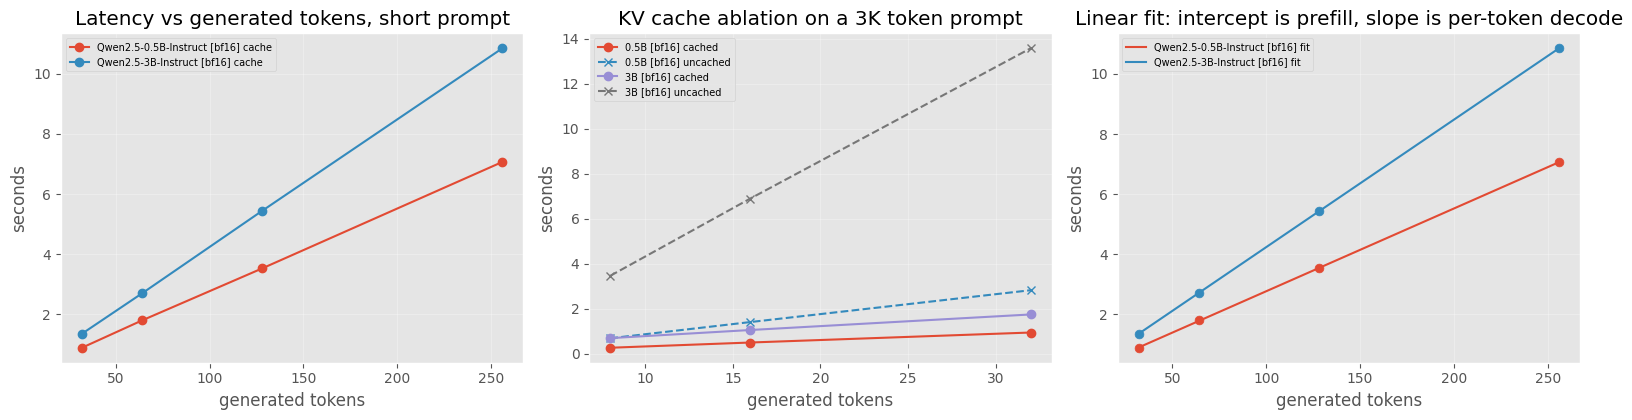

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))

for model_label in cached["model"].unique():
    sub = cached[cached["model"] == model_label].sort_values("output_tokens")
    axes[0].plot(sub["output_tokens"], sub["seconds"], marker="o", label=f"{model_label} cache")

axes[0].set_title("Latency vs generated tokens, short prompt")
axes[0].set_xlabel("generated tokens")
axes[0].set_ylabel("seconds")
axes[0].legend(fontsize=7)
axes[0].grid(alpha=0.3)

for _, row in pd_df.iterrows():
    xs = np.array(OUTPUT_LENGTHS)
    axes[2].plot(xs, row["prefill_seconds"] + row["seconds_per_decoded_token"] * xs,
                 label=f"{row['model']} fit")
    sub = cached[cached["model"] == row["model"]].sort_values("output_tokens")
    axes[2].scatter(sub["output_tokens"], sub["seconds"], s=40)
axes[2].set_title("Linear fit: intercept is prefill, slope is per-token decode")
axes[2].set_xlabel("generated tokens")
axes[2].set_ylabel("seconds")
axes[2].legend(fontsize=7)
axes[2].grid(alpha=0.3)

for model_label in ablation["model"].unique():
    for mode, marker in [("cached", "o"), ("uncached", "x")]:
        sub = ablation[(ablation["model"] == model_label) & (ablation["mode"] == mode)]
        sub = sub.sort_values("requested_tokens")
        axes[1].plot(sub["requested_tokens"], sub["seconds"], marker=marker,
                     linestyle="-" if mode == "cached" else "--",
                     label=f"{model_label.replace('Qwen2.5-', '').replace('-Instruct', '')} {mode}")
axes[1].set_title("KV cache ablation on a 3K token prompt")
axes[1].set_xlabel("generated tokens")
axes[1].set_ylabel("seconds")
axes[1].legend(fontsize=7)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שלושה דברים שהגרפים מראים:</p>
<ul>
<li>הישרים בגרף השמאלי מושלמים, בלי עקמומיות בשני המודלים. באורכי פלט של עד 256 טוקנים אין תרומה נראית לעלות הריבועית של הקשב</li>
<li>הממצא החזק ביותר באמצע: 3B עם מטמון מסיים ב-1.74 שניות, מהר מ-0.5B בלעדיו ב-2.82. המטמון שווה יותר מפי שישה בפרמטרים</li>
<li>קו ה-3B ללא מטמון תלול בסדר גודל מהשאר. הוא היחיד שבו העלות היא מכפלה של גודל המודל באורך הרצף, בלי מבנה שמונע חישוב חוזר</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>פענוח ספקולטיבי: ה-0.5B מנסח טיוטה וה-3B מאמת אותה במקביל. identical_output בודק את הנכונות: הפלט אמור להיות זהה ל-greedy.</p>
</div>

In [ ]:
spec_rows = []
if INCLUDE_SPECULATIVE and MODEL_IDS.get("assistant"):
    target_id = MODEL_IDS["large"]
    label = target_id.split("/")[-1]
    print(f"loading {label} with assistant {MODEL_IDS['assistant']} ...")
    try:
        model, tok = load_model(target_id)
        assistant, _ = load_model(MODEL_IDS["assistant"])
        for n_tokens in [64, 128]:
            base = generate_once(model, tok, EFF_PROMPT, max_new_tokens=n_tokens, do_sample=False)
            sync()
            started = time.perf_counter()
            inputs = encode_chat(tok, EFF_PROMPT)
            inputs = {k: v.to(model.device) for k, v in inputs.items() if isinstance(v, torch.Tensor)}
            input_len = inputs["input_ids"].shape[-1]
            with torch.no_grad():
                out = model.generate(**inputs, max_new_tokens=n_tokens, do_sample=False,
                                     assistant_model=assistant,
                                     pad_token_id=tok.pad_token_id if tok.pad_token_id is not None else tok.eos_token_id)
            sync()
            spec_seconds = round(time.perf_counter() - started, 4)
            spec_text = decode_text(tok, out[0][input_len:]).strip()
            spec_tokens = int(out[0].shape[-1] - input_len)
            spec_rows.append({
                "requested_tokens": n_tokens,
                "baseline_seconds": base["seconds"],
                "speculative_seconds": spec_seconds,
                "speedup": round(base["seconds"] / spec_seconds, 2) if spec_seconds > 0 else None,
                "baseline_tokens": base["output_tokens"],
                "speculative_tokens": spec_tokens,
                "identical_output": spec_text == base["text"],
            })
        del model, assistant, tok
        free_gpu()
        spec_df = pd.DataFrame(spec_rows)
        print(spec_df.to_string(index=False))
        RESULTS["part_e_speculative"] = spec_df.to_dict("records")
    except Exception as exc:
        print(f"speculative decoding skipped: {type(exc).__name__}: {exc}")
        RESULTS["part_e_speculative"] = []
else:
    print("speculative decoding disabled in the run plan, section skipped")
    RESULTS["part_e_speculative"] = []


loading Qwen2.5-3B-Instruct with assistant Qwen/Qwen2.5-0.5B-Instruct ...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'use_cache', 'min_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.RepetitionPenaltyLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.RepetitionPenaltyLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.RepetitionPenaltyLogitsProcessor'> to see related `.generate()` flags.


 requested_tokens  baseline_seconds  speculative_seconds  speedup  baseline_tokens  speculative_tokens  identical_output
               64            2.7283               3.8492     0.71               64                  64              True
              128            5.4725               8.1119     0.67              128                 128             False


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שלושה ממצאים:</p>
<ul>
<li>התוצאה שלילית: 0.71 ו-0.67, כלומר הפענוח הספקולטיבי איטי ב-30% עד 40% מ-greedy רגיל. ההרחבה לא שיפרה דבר</li>
<li>ההסבר במדידות שלנו: הטיוטה מהירה מהמטרה פי 1.54 בלבד — 27.5 מול 42.4 מילישניות לטוקן. בפער כזה ההרצה הכפולה בולעת אותו</li>
<li>ב-128 טוקנים identical_output יוצא False והפלט סטה מ-greedy. השיטה שקולה מתמטית, ולכן החשוד הוא עונש החזרתיות שהופעל פעמיים</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ממצאים ומסקנות — חלק ה׳:</p>
<ul>
<li>הפירוק: השיפוע נותן 27.5 ו-42.4 מילישניות לטוקן, והחיתוך 19.6 מילישניות בקטן ושלילי מעט בגדול — ערך שלילי אינו זמן prefill אלא סימן שההתאמה על ארבע נקודות אינה אומדת אותו באמינות; השיפוע הוא המדד. ה-prompt מנה 63 טוקנים, ולכן ה-prefill זניח וכל העלות היא decode</li>
<li>בדיקת השפיות נכשלת חלקית: החיתוך אמור להיות בסדר גודל של הזמן לטוקן הראשון, 33.5 ו-49.1, והוא נמוך ממנו. הזמן כולל תקורה קבועה</li>
<li>נקודת המעבר ברורה מהמספרים: 63 טוקני קלט מול 256 פלט הם משטר decode מובהק, ו-2,853 מול 8 הפכו את היחס</li>
<li>המטמון מאיץ פי 2.62 עד 3.01 בקטן ופי 5.03 עד 7.80 בגדול, וההאצה גדלה עם אורך הפלט. ההשוואה היא ablation ידני — בלי מטמון בוצע מעבר קדימה מלא בכל צעד בלולאה — ולא מדידה של שני מסלולי הסקה ממוטבים. התקרה היא 3.2 ו-9.6, וההפרש הוא ה-prefill</li>
<li>הזיכרון: הנוסחה נותנת 0.375 ו-1.125 GiB ב-32K, מול 1.35 ו-3.31 שנמדדו בחלק ג׳. המטמון אינו הדומיננטי אלא מבני ה-prefill</li>
<li>GQA מסביר את המספרים: 14 ראשי query מול 2 בקטן ו-16 מול 2 בגדול. אין חלון הזזה, ולכן החישוב מדויק ואינו חסם עליון</li>
<li>מה לא ניתן להסיק: הפענוח הספקולטיבי יצא 0.71 ו-0.67, אך על זוג מודלים אחד. זו אינה שלילת השיטה אלא של הזוג</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>חלק ו׳ — Failure Forensics</p>
<p>מטרת החלק: לאסוף כשלים באופן שיטתי ולבנות טקסונומיה, במקום אוסף דוגמאות מצחיקות.</p>
<p>ההבדל מהותי: כל כשל נאסף אוטומטית ברגע שהתשובה לא עמדה בקריטריון מראש. אף דוגמה לא נבחרה בדיעבד, ונשמרו הפלט והתנאים.</p>
<p>הקטגוריות נגזרות ממקור הכשל: שגיאה עובדתית, עמידה בהוראות, הנמקה, יצירת קוד, רב-לשוניות והקשר ארוך.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הטקסונומיה נבנית משני חתכים: קטגוריה מול מודל, וספירה לכל קטגוריה. החתך לפי מודל חיוני, כי לא כל מודל רץ בכל חלק.</p>
</div>

In [ ]:
fail_df = pd.DataFrame(FAILURES)
print(f"total failures collected across parts B to E: {len(fail_df)}")
print()
if len(fail_df):
    taxonomy = (fail_df.groupby(["category", "model"]).size()
                .unstack(fill_value=0))
    print("FAILURE TAXONOMY")
    print(taxonomy.to_string())
    print()
    print("FAILURES BY CATEGORY")
    print(fail_df["category"].value_counts().to_string())
    RESULTS["part_f_taxonomy"] = taxonomy.to_dict()
    RESULTS["part_f_counts"] = fail_df["category"].value_counts().to_dict()
else:
    print("no failures were collected, which itself is a finding worth reporting")
    RESULTS["part_f_taxonomy"] = {}
    RESULTS["part_f_counts"] = {}

total failures collected across parts B to E: 275

FAILURE TAXONOMY
model                  Qwen2.5-0.5B-Instruct [bf16]  Qwen2.5-1.5B-Instruct [bf16]  Qwen2.5-3B-Instruct [bf16]
category                                                                                                     
code_generation                                   4                             0                           0
factual_error                                   151                             0                          74
instruction_following                             2                             2                           0
long_context                                      8                             0                           3
long_context_multihop                             6                             0                           1
multilingual                                      5                             3                           3
reasoning                                         5 

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ארבעה ממצאים:</p>
<ul>
<li>שכיחות אינה חומרה: 225 מתוך 275 הם factual_error, כי כל הרצה של שאלה שהמודל לא ידע נספרה מחדש בשש התצורות</li>
<li>הטבלה מערבת חשיפה: ה-1.5B רץ רק בחלק ד׳, ולכן האפסים שלו אינם הצלחה אלא היעדר. ההשוואה תקפה רק בקטגוריות מחלק ד׳</li>
<li>ובהן הספירות תואמות את ציוני חלק ד׳ פריט בפריט. הטקסונומיה והבנצ'מרק מסכימים</li>
<li>הכשלים המעניינים נדירים: 11 בהקשר ארוך, 7 בדו-שלבי, 4 בקוד ו-4 בהוראות. אלה נצפו ב-greedy ולכן הם כשלי יכולת, לא רעש דגימה</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שתי דוגמאות מכל קטגוריה, עם התנאים שבהם התרחשו. המטלה דורשת אחת לפחות, ושתיים מראות אם הכשל חוזר או מקרי.</p>
</div>

In [ ]:
if len(fail_df):
    for category in fail_df["category"].unique():
        subset = fail_df[fail_df["category"] == category]
        print("=" * 100)
        print(f"CATEGORY: {category}   ({len(subset)} occurrences)")
        for _, row in subset.head(2).iterrows():
            print(f"  model    : {row['model']}")
            print(f"  prompt   : {row['prompt'][:140]}")
            print(f"  output   : {row['output'][:140]}")
            print(f"  expected : {row['expected']}")
            print(f"  condition: {row['note']}")
            print()
    RESULTS["part_f_examples"] = fail_df.to_dict("records")

CATEGORY: factual_error   (225 occurrences)
  model    : Qwen2.5-0.5B-Instruct [bf16]
  prompt   : What is the chemical symbol for gold? Reply with the symbol only.
  output   : Au(Customer Bu Ferrそんな彼もの远处NES)**델揸 الإنحرك troop td
  expected : au
  condition: decoding=temp_extreme

  model    : Qwen2.5-0.5B-Instruct [bf16]
  prompt   : What is the chemical symbol for gold? Reply with the symbol only.
  output   : MahmIONS serum rem Collection XD terminal蛭 skin研究中心experience replacr CI Mej钉
  expected : au
  condition: decoding=temp_extreme

CATEGORY: long_context   (11 occurrences)
  model    : Qwen2.5-0.5B-Instruct [bf16]
  prompt   : Read the document above. What is the access code for PROJECT ORION? Reply with the code only, in the exact format shown in the document.
  output   : CAR-1746-CX
  expected : ORN-7719-QX
  condition: position=middle ctx=8439 distractors=False

  model    : Qwen2.5-0.5B-Instruct [bf16]
  prompt   : Read the document above. What is the access code for PROJ

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>חמישה ממצאים מהדוגמאות עצמן:</p>
<ul>
<li>ארבעת כשלי הקוד אינם כשלי קוד: הפונקציה ב-code_1 נכונה, אך אחרי הגדר הסוגרת בא הסבר, ו-strip_code_fences מסיר גדר רק בסוף</li>
<li>המסיח בדו-שלבי אינו אקראי: אותו 7051 נבחר בשני מיקומים שונים באותו אורך. המודל נועל על תג אחד ולא מגריל</li>
<li>האחזור החלקי חשוף כאן: "7719-QX" מכיל את הספרות הנכונות בלי התחילית. המודל מצא את המקום ואיבד את תחילת המחרוזת</li>
<li>בעברית מופיעים שני כשלים בו-זמנית: החלפת שפה באמצע משפט — "מרכז geographical" — ותשובה שגויה עובדתית</li>
<li>instr_6 ביקש ארבע מילים וקיבל ארבעה משפטים. זו אינה התעלמות מהאילוץ אלא פירוש שגוי של יחידת הספירה</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הניסוי בוחר פריט הנמקה שנכשל ומריץ עליו ארבעה נוסחים: המקורי, פירוט שלבים, פירוק ידני ומספרים אחרים. הציון מחמיר: נלקח המספר האחרון.</p>
</div>

In [ ]:
MINIMAL_PAIR_SETS = {
    "reason_1": [
        ("original", "A shop sells pens at 3 shekels each. Dana buys 7 pens and pays with a 50 shekel note. How much change does she get? Reply with the number only.", "29", 24),
        ("step_by_step", "A shop sells pens at 3 shekels each. Dana buys 7 pens and pays with a 50 shekel note. How much change does she get? Work through the calculation step by step, then write the final number alone on the last line.", "29", 160),
        ("decomposed", "A shop sells pens at 3 shekels each. Dana buys 7 pens. First compute the total price of the pens, then subtract it from the 50 shekel note she pays with. Reply with the final number only.", "29", 48),
        ("other_numbers", "A shop sells notebooks at 4 shekels each. Noa buys 6 notebooks and pays with a 100 shekel note. How much change does she get? Reply with the number only.", "76", 24),
    ],
    "reason_4": [
        ("original", "A rectangle has perimeter 36 and one side of length 10. What is the area? Reply with the number only.", "80", 24),
        ("step_by_step", "A rectangle has perimeter 36 and one side of length 10. What is the area? Work through the calculation step by step, then write the final number alone on the last line.", "80", 160),
        ("decomposed", "A rectangle has perimeter 36 and one side of length 10. First compute the other side: half the perimeter minus 10. Then multiply the two sides. Reply with the final number only.", "80", 48),
        ("other_numbers", "A rectangle has perimeter 40 and one side of length 12. What is the area? Reply with the number only.", "96", 24),
    ],
    "reason_5": [
        ("original", "Yossi is twice as old as Rina. In 6 years their combined age will be 42. How old is Rina now? Reply with the number only.", "10", 24),
        ("step_by_step", "Yossi is twice as old as Rina. In 6 years their combined age will be 42. How old is Rina now? Work through the calculation step by step, then write the final number alone on the last line.", "10", 160),
        ("decomposed", "Yossi is twice as old as Rina. In 6 years their combined age will be 42. First compute their combined age today by subtracting 12 from 42. Then divide that by 3 to get Rina's age. Reply with the final number only.", "10", 48),
        ("other_numbers", "Yossi is twice as old as Rina. In 4 years their combined age will be 47. How old is Rina now? Reply with the number only.", "13", 24),
    ],
}

def reasoning_failures_for(role):
    prefix = MODEL_IDS[role].split("/")[-1]
    return [f["note"].replace("benchmark item ", "") for f in FAILURES
            if f["category"] == "reasoning" and f["model"].startswith(prefix)]

chosen_role, chosen_item = None, None
for role in ["small", "large"]:
    failed = reasoning_failures_for(role)
    hit = next((item for item in MINIMAL_PAIR_SETS if item in failed), None)
    if hit:
        chosen_role, chosen_item = role, hit
        break
if chosen_item is None:
    chosen_role, chosen_item = "small", "reason_1"
    print("no reasoning failure matched a prepared set; running reason_1 on the small model as a stability check")
else:
    print(f"minimal pair targets {chosen_item}, an observed failure of the {chosen_role} model")

mp_rows = []
label = MODEL_IDS[chosen_role].split("/")[-1] + " [bf16]"
print(f"loading {label} for the minimal pair experiment ...")
model, tok = load_model(MODEL_IDS[chosen_role])
for variant, prompt, gold, budget in MINIMAL_PAIR_SETS[chosen_item]:
    out = generate_once(model, tok, prompt, max_new_tokens=budget, do_sample=False)
    numbers = re.findall(r"-?\d+", out["text"])
    final_number = numbers[-1] if numbers else ""
    mp_rows.append({
        "item": chosen_item,
        "variant": variant,
        "gold": gold,
        "final_number": final_number,
        "correct": final_number == gold,
        "output_tokens": out["output_tokens"],
        "output": out["text"][:90].replace("\n", " | "),
    })
del model, tok
free_gpu()

mp_df = pd.DataFrame(mp_rows)
print()
print(f"MINIMAL PAIR ON {chosen_item} ({label}): one change per variant")
print(mp_df.to_string(index=False))
RESULTS["part_f_minimal_pair"] = mp_df.to_dict("records")
RESULTS["part_f_minimal_pair_target"] = {"role": chosen_role, "item": chosen_item}

minimal pair targets reason_1, an observed failure of the small model
loading Qwen2.5-0.5B-Instruct [bf16] for the minimal pair experiment ...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]


MINIMAL PAIR ON reason_1 (Qwen2.5-0.5B-Instruct [bf16]): one change per variant
    item       variant gold final_number  correct  output_tokens                                                                                         output
reason_1      original   29            2    False              5                                                                                      2 shekels
reason_1  step_by_step   29           21    False            160 To determine how much change Dana gets, we need to follow these steps: |  | 1. Calculate the t
reason_1    decomposed   29            7    False             48 The total price of the pens is \(7 \times 3 = 21\) shekels. |  | Dana has 50 shekels and needs
reason_1 other_numbers   76           40    False             13                                                                 Noa gets 40 shekels as change.


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ארבעה ממצאים:</p>
<ul>
<li>כל ארבעת הנוסחים נכשלו, אך רק שניים מהם מסקנתיים, ראו סעיף 3. בשניים אלה החלפת המספרים והשמות לא שינתה דבר — עקבי עם מגבלת יכולת ולא עם רגישות לניסוח</li>
<li>החוליה הראשונה דווקא עובדת: בשני הנוסחים הארוכים מופיע 7×3=21 נכון. מה שנשבר בנוסחים שהסתיימו הוא החיסור מ-50, כלומר השלב השני ולא החישוב עצמו</li>
<li>שני הנוסחים הארוכים נקטעו בתקרה ואינם מסקנתיים. ההשוואה הנקייה היא בין המקורי ל-other_numbers, ששניהם הסתיימו ושגו</li>
<li>final_number מחלץ את המספר האחרון, ובפלט קטוע זה מספר ביניים ולא תשובה. 7 ב-decomposed הוא כמות העטים, לא תוצאה</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ממצאים ומסקנות — חלק ו׳:</p>
<ul>
<li>שגיאה עובדתית, 225: sb_element נכשל בכל התצורות בקטן ונפתר בגדול. ההסבר הוא ידע חסר. אבחון: אותה שאלה כ-few-shot עם שתי דוגמאות מאותו תחום; אם היא נפתרת, הידע קיים והבעיה בשליפה</li>
<li>עמידה בהוראות, 4: instr_4 החזיר מספר במרכאות ו-instr_6 משפטים במקום מילים. ההסבר הוא כוונון לתשובה מלאה; אבחון בלי "exactly"</li>
<li>הנמקה, 13: ב-reason_1 החוליה הראשונה נכונה — 7×3=21 — והחיסור נשבר. הזוג המינימלי נכשל בשני הנוסחים שהסתיימו, עקבי עם מגבלת יכולת. אבחון: שתי בעיות של שלב אחד — כפל בלבד וחיסור בלבד — כדי לבודד את החוליה שנשברת</li>
<li>יצירת קוד, 4: הקוד נכון, אך המודל הוסיף הסבר אחרי הגדר ו-strip_code_fences מסיר גדר רק בסוף. זהו כשל מדידה. אבחון: אותם פריטים עם חילוץ בלוק הקוד הראשון במקום הסרת גדרות; אם הציון עולה ל-1.000, הכשל כולו במדידה</li>
<li>רב-לשוניות, 11: הפלט מחליף שפה באמצע משפט ונשאר 5/3/3 בין הגדלים. אבחון: אותן שאלות באנגלית; אם הפער נסגר, הבעיה בשפה</li>
<li>הקשר ארוך, 11 ועוד 7 דו-שלביים: המודל מחזיר קוד מילוי או ספרות בלי תחילית, ונועל על אותו תג. אבחון: אותה עובדה ב-2K</li>
</ul>
<p>מה לא ניתן להסיק: הספירות אינן מדד לחומרה. הגדולה נובעת מכך שכל הרצה נספרה בנפרד, והקטנות נצפו ב-greedy ולכן המעניינות.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>דו"ח פורנזי מסכם — Forensic Profile:</p>
<ul>
<li>מה המודל עושה טוב: אחזור מסוף ההקשר, 24 מתוך 24 בשלוש הבדיקות, בשני הגדלים ובכל האורכים עד 30K. קוד מגיע ל-1.000 כבר ב-1.5B, וגם ב-0.5B הפונקציות נכונות ורק הפורמט נכשל</li>
<li>נקודות החולשה: הנמקה נשארת 0.500 גם ב-3B, והזוג המינימלי נכשל בכל ארבעת הנוסחים שנבדקו. עברית תקועה על 5/3/3, וגודל אינו פותר אותה</li>
<li>ה-trade-off: פי 6.25 במשקולות קונה פי 2.25 באיכות ומייקר את הטוקן ל-43.1 מילישניות. אך המטמון שווה יותר: 3B איתו מהיר מ-0.5B בלעדיו החל מ-16 טוקני פלט</li>
<li>ההפתעה: דגימה שיפרה את הדיוק העובדתי בקטן, מ-0.375 ל-0.550. הציפייה הייתה שאקראיות תזיק, אך הנכונה קיימת ואינה השכיחה</li>
<li>מסקנה חזקה: עלות הפענוח לטוקן, שנמדדה פעמיים בחלקים נפרדים ועל משימות שונות — 27.5 מול 27.8 ו-42.4 מול 43.1</li>
<li>מסקנה ספקולטיבית: הקו הישר בחלק ד׳ נשען על שלוש נקודות, והתוצאה השלילית של הפענוח הספקולטיבי על זוג אחד</li>
</ul>
<p>עובדה מול הסקה: יחסי ה-GQA, מספר השכבות וחלון ה-32K מתועדים בקונפיגורציה. כל השאר במחברת הוא הסקה ממדידה על קופסה שחורה.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>בונוס — סוויפ קוונטיזציה</p>
<p>הניסוי מבודד את הדיוק: אותו 3B, אותו benchmark ואותו פענוח greedy, בשלוש רמות — bf16 מחלק ד׳, 8-bit ו-4-bit NF4 עם קוונטיזציה כפולה.</p>
<p>נמדדים זיכרון המשקולות, זמן ממוצע לדוגמה וציון לפי סוג משימה.</p>
<p>החיבור לחלק ד׳: 3B ב-4-bit תופס פחות זיכרון מ-1.5B ב-bf16, ושניהם נמדדו על אותו benchmark. בתקציב נתון — גדול ומקוונטז או קטן ומלא?</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שורות ה-bf16 נלקחות מחלק ד׳ ולא מורצות מחדש, כדי שההשוואה תהיה מול אותה הרצה. הרמות המקוונטזות עטופות ב-try מפני כישלון טעינה.</p>
</div>

In [ ]:
quant_rows = [dict(row, precision="bf16") for row in bench_rows
              if row["model"] == MODEL_IDS["large"].split("/")[-1]]
quant_load = {"bf16": LOAD_STATS.get(
    f'{MODEL_IDS["large"].split("/")[-1]}|bf16', {})}

for quant in BONUS_PRECISIONS:
    precision = quant
    label = MODEL_IDS["large"].split("/")[-1]
    print(f"loading {label} [{precision}] ...")
    try:
        reset_peak_memory()
        baseline_gib = torch.cuda.memory_allocated() / 2**30 if torch.cuda.is_available() else 0.0
        started = time.perf_counter()
        model, tok = load_model(MODEL_IDS["large"], quant=quant)
        load_seconds = round(time.perf_counter() - started, 2)
        resident_gib = round(torch.cuda.memory_allocated() / 2**30 - baseline_gib, 3) \
            if torch.cuda.is_available() else 0.0
        quant_load[precision] = {"load_seconds": load_seconds, "weights_gib": resident_gib}
        print(f"  loaded in {load_seconds}s, resident weights {resident_gib} GiB")
        quant_rows += run_benchmark(model, tok, label, precision)
        del model, tok
        free_gpu()
    except Exception as exc:
        print(f"  skipped {precision}: {type(exc).__name__}: {exc}")

quant_df = pd.DataFrame(quant_rows)
RESULTS["part_bonus_raw"] = quant_df.to_dict("records")
RESULTS["part_bonus_load"] = quant_load
print()
print(f"collected {len(quant_df)} benchmark results across "
      f"{quant_df['precision'].nunique() if len(quant_df) else 0} precisions")

loading Qwen2.5-3B-Instruct [8bit] ...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

  loaded in 10.19s, resident weights 3.168 GiB


Streaming output truncated to the last 5000 lines.


  [ 6/24] running mean=0.83     13s


...

  [18/24] running mean=0.78    107s


Streaming output truncated to the last 5000 lines.


  [24/24] running mean=0.71    120s
loading Qwen2.5-3B-Instruct [4bit] ...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

  loaded in 4.68s, resident weights 1.914 GiB
  [ 6/24] running mean=1.00      2s
  [12/24] running mean=0.67      3s
  [18/24] running mean=0.78     17s
  [24/24] running mean=0.71     20s

collected 72 benchmark results across 3 precisions


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שלושה דברים שרואים רק בלוג ההרצה:</p>
<ul>
<li>הממוצעים הרצים נפרדים רק בנקודה הראשונה, 0.83 ב-8-bit מול 1.00 ב-4-bit, ומשם זהים לחלוטין: 0.67, 0.78, 0.71. הטבלה המסכמת אינה יכולה להראות זאת</li>
<li>הזמן המצטבר ב-8-bit אינו אחיד: 13, 20, 107 ו-120 שניות — 87 שניות לפריטים 13 עד 18 לבדם, מול 20 לשנים-עשר הראשונים</li>
<li>אלפי אזהרות MatMul8bitLt אינן שגיאות אלא תיעוד של המרה מ-bfloat16 ל-float16 בכל כפל; הן חתכו את הפלט שלוש פעמים, ושורת הטעינה של 8-bit שרדה רק ב-quant_load</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>סיכום הסוויפ בארבעה פלטים:</p>
<ul>
<li>טבלת איכות לפי סוג משימה, כדי לראות היכן מתרכז הנזק ולא רק את גודלו הכולל</li>
<li>טבלת עלות — זמן, זיכרון, משקולות וטעינה — ואחריה הפרש הציון מול bf16 לצד נפח המשקולות, שתי הפאות של אותה החלטה</li>
<li>הטקסונומיה מודפסת מחדש, משום שהכשלים מהרמות המקוונטזות נאספו אחרי שהודפסה בחלק ו׳</li>
<li>גרף בשני צירים: הציון בעמודות מול נפח המשקולות בקו, כי הטענה כאן היא על היחס ביניהם ולא על אף אחד מהם בנפרד</li>
</ul>
</div>

QUANTIZATION SWEEP: QUALITY (same model, same benchmark, greedy decoding)
kind       code  hebrew  instruction  reasoning  overall
precision                                               
4bit        1.0     0.5        1.000      0.333    0.708
8bit        1.0     0.5        0.833      0.500    0.708
bf16        1.0     0.5        1.000      0.500    0.750

QUANTIZATION SWEEP: COST
           mean_seconds  peak_gib  weights_gib  load_seconds
precision                                                   
4bit              0.835     1.973        1.914          4.68
8bit              5.003     3.234        3.168         10.19
bf16              0.537     5.765        5.748          4.16

  4bit   overall=0.708  delta_vs_bf16=-0.042  weights=1.914 GiB
  8bit   overall=0.708  delta_vs_bf16=-0.042  weights=3.168 GiB
  bf16   overall=0.750  delta_vs_bf16=+0.000  weights=5.748 GiB

FAILURE TAXONOMY UPDATED WITH THE QUANTIZATION SWEEP
model                  Qwen2.5-0.5B-Instruct [bf16]  Qwen2.5-1.

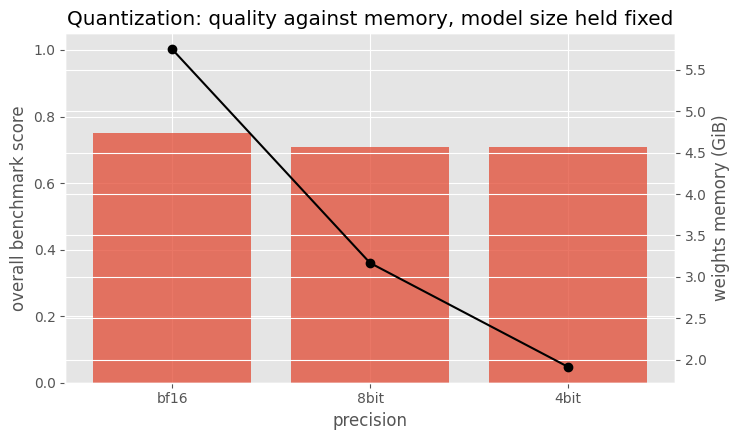

In [ ]:
if len(quant_df):
    q_quality = (quant_df.groupby(["precision", "kind"])["score"].mean()
                 .unstack("kind").round(3))
    q_quality["overall"] = quant_df.groupby("precision")["score"].mean().round(3)
    q_cost = (quant_df.groupby("precision")
              .agg(mean_seconds=("seconds", "mean"),
                   peak_gib=("peak_gib", "max")).round(3))
    q_cost["weights_gib"] = [quant_load.get(p, {}).get("weights_gib") for p in q_cost.index]
    q_cost["load_seconds"] = [quant_load.get(p, {}).get("load_seconds") for p in q_cost.index]

    print("QUANTIZATION SWEEP: QUALITY (same model, same benchmark, greedy decoding)")
    print(q_quality.to_string())
    print()
    print("QUANTIZATION SWEEP: COST")
    print(q_cost.to_string())

    baseline = q_quality.loc["bf16", "overall"] if "bf16" in q_quality.index else None
    if baseline is not None:
        print()
        for precision in q_quality.index:
            delta = q_quality.loc[precision, "overall"] - baseline
            mem = q_cost.loc[precision, "weights_gib"]
            print(f"  {precision:6s} overall={q_quality.loc[precision, 'overall']:.3f}  "
                  f"delta_vs_bf16={delta:+.3f}  weights={mem} GiB")

    RESULTS["part_bonus_quality"] = q_quality.reset_index().to_dict("records")
    RESULTS["part_bonus_cost"] = q_cost.reset_index().to_dict("records")

    updated_fail = pd.DataFrame(FAILURES)
    updated_tax = (updated_fail.groupby(["category", "model"]).size().unstack(fill_value=0))
    print()
    print("FAILURE TAXONOMY UPDATED WITH THE QUANTIZATION SWEEP")
    print(updated_tax.to_string())
    RESULTS["part_f_taxonomy_with_bonus"] = updated_tax.to_dict()

    fig, ax1 = plt.subplots(figsize=(7.5, 4.5))
    order = [p for p in ["bf16", "8bit", "4bit"] if p in q_quality.index]
    ax1.bar(order, [q_quality.loc[p, "overall"] for p in order], alpha=0.75)
    ax1.set_ylabel("overall benchmark score")
    ax1.set_xlabel("precision")
    ax1.set_ylim(0, 1.05)
    ax2 = ax1.twinx()
    ax2.plot(order, [q_cost.loc[p, "weights_gib"] for p in order],
             marker="o", color="black", label="weights GiB")
    ax2.set_ylabel("weights memory (GiB)")
    ax1.set_title("Quantization: quality against memory, model size held fixed")
    plt.tight_layout()
    plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שמונה ממצאים מהטבלאות:</p>
<ul>
<li>אותו ציון, נזק אחר: שתיהן ל-0.708, אך 8-bit מפיל פריט הוראות, 1.000 ל-0.833, ו-4-bit הנמקה, 0.500 ל-0.333. קוד ועברית לא נפגעו</li>
<li>החשבון מאשר: 311 מיליון embedding ב-16 סיביות, 2.78 מיליארד ב-8 נותנים 3.16 GiB, מול 3.168 שנמדד. ב-4-bit 0.040 GiB קבועי הקוונטיזציה</li>
<li>העלות אינה סימטרית: 8-bit לוקח 5.003 שניות לפריט מול 0.537 ב-bf16 ו-0.835 ב-4-bit, ונטען לאט, 10.19 מול 4.16 ו-4.68. מסלול ה-int8 של bitsandbytes יקר במימוש הזה</li>
<li>ההפרש בין השיא למשקולות גדל במקוונטזים, 0.066 ו-0.059 מול 0.017 GiB: על אותם פריטים האקטיבציות זהות, ולכן התוספת היא כנראה חוצצי ה-dequantization של bitsandbytes</li>
<li>בגרף העמודות כמעט זהות בעוד קו הזיכרון צונח פי שלושה. ההשוואה: 3B ב-4-bit תופס 1.914 GiB ומשיג 0.708, מול 2.875 ו-0.583 ב-1.5B</li>
<li>שתי ציפיות סבירות מראש לא התאמתו: 4-bit לא היה איטי מ-8-bit, וקוד לא נפגע מהקוונטיזציה</li>
<li>הסתייגות מדגם: 0.042 הוא 1 חלקי 24, פריט בודד. אין הספק להבחין בשלוש הרמות, והניסוח הזהיר שלא נצפתה הידרדרות מעבר לפריט אחד</li>
<li>הסתייגות מדידה: ספירות הכשלים של הרמות המקוונטזות בטקסונומיה כפולות בדיוק מהמתחייב מהציונים — למשל 2 כשלי הוראות ב-8-bit מול 0.833 שמשמעו כשל אחד — עקבי עם הרצה חוזרת של תא הסוויפ שצברה את FAILURES פעמיים. בנוסף, ל-bf16 נרשמו 74 כשלי factual_error מחלקים ב׳–ג׳, ולכן העמודות אינן ברות השוואה</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>מגבלות המחקר:</p>
<ul>
<li>גדלי Qwen2.5 אומנו בנפרד, אך הרכב הדאטה ותקציב האימון לכל גודל אינם מפורסמים, ולכן אפקט הגודל אינו מבודד מהבדלי אימון</li>
<li>ה-benchmark מונה 24 פריטים, שישה לכל סוג משימה. פריט אחד שווה 0.167 בציון סוג משימה, ולכן פריט או שניים הם בטווח הרעש</li>
<li>חלק ג׳ נבדק עד 30 אלף טוקנים, קרוב לקצה חלון ההקשר המוצהר 32,768. המסקנות תקפות למסמך הסינתטי ולא לטקסט טבעי ארוך</li>
<li>החישוב התיאורטי של מטמון ה-KV נשען על הקונפיגורציה והוצלב מול גידול הזיכרון בחלק ג׳, אך אינו מודד את המטמון ישירות</li>
<li>כל המדידות בוצעו על כרטיס יחיד המתועד בתא הסביבה, ולכן מספרי הלטנציה אינם ניתנים להעברה לחומרה אחרת</li>
<li>כל הניסויים מודדים התנהגות קלט-פלט. שום מסקנה אינה נוגעת למנגנון הפנימי, לא ל-RoPE, לא למפות הקשב ולא לייצוגים החבויים</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>סיכום כולל:</p>
<ul>
<li>שישה חלקי חובה ובונוס אחד נמדדו על אותה משפחת מודלים, Qwen2.5-Instruct, כאשר כל חלק בודק היבט אחר של אותה קופסה שחורה: ייצוג הקלט, אסטרטגיית הפלט, השימוש בהקשר, אפקט הגודל, עלות ההסקה ודפוסי הכשל</li>
<li>הזוג הראשי 0.5B מול 3B הורץ כולו ב-bf16, והנקודה האמצעית 1.5B הורצה באותו דיוק, כך שההשוואה בין גדלים משנה גורם נשלט אחד, בכפוף למגבלת הבדלי האימון שלעיל</li>
<li>הכשלים נאספו אוטומטית כשתשובה לא עמדה בקריטריון שהוגדר מראש, ולכן הטקסונומיה בחלק ו׳ נשענת על ראיות ולא על דוגמאות נוחות</li>
<li>סוויפ הקוונטיזציה בבונוס מבודד את הדיוק כשהגודל קבוע, ומאפשר להשוות מודל גדול מקוונטז למודל קטן בדיוק מלא באותו תקציב זיכרון</li>
<li>כל טבלה מודפסת מהתא שחישב אותה, והמספרים הבודדים שחושבו ידנית, כמו פירוק הזיכרון בבונוס, מסומנים ככאלה</li>
<li>מגבלות שיש לזכור: 24 פריטים, כרטיס יחיד, והתנהגות קלט-פלט בלבד — כמפורט בתא הקודם</li>
</ul>
</div>